# Designing and Evaluating an Adaptive, Explainable Interface for Bangla Smishing Detection

## 1. Environment & hardware

In [1]:
import os, sys, platform, random, time, json, math, re, gc, hashlib, warnings, unicodedata
warnings.filterwarnings("ignore")
from pathlib import Path
from collections import Counter

import torch

try:
    import psutil
except Exception:
    psutil = None

print("=" * 74)
print("ENVIRONMENT & HARDWARE")
print("=" * 74)
print(f"Python version       : {platform.python_version()}")
print(f"Platform             : {platform.platform()}")
print(f"CPU                  : {platform.processor() or 'unknown'}")
print(f"CPU cores (logical)  : {os.cpu_count()}")
if psutil:
    vm = psutil.virtual_memory()
    print(f"System RAM total     : {vm.total/1e9:.2f} GB")
    print(f"System RAM available : {vm.available/1e9:.2f} GB")
print(f"PyTorch version      : {torch.__version__}")
print(f"PyTorch CUDA build   : {torch.version.cuda}")
print(f"CUDA available       : {torch.cuda.is_available()}")

BF16_OK = False
if torch.cuda.is_available():
    p = torch.cuda.get_device_properties(0)
    print(f"GPU name             : {p.name}")
    print(f"GPU memory total     : {p.total_memory/1e9:.2f} GB")
    print(f"GPU compute cap.     : sm_{p.major}{p.minor}")
    try:
        BF16_OK = torch.cuda.is_bf16_supported()
    except Exception:
        BF16_OK = p.major >= 8
    print(f"BF16 supported       : {BF16_OK}")

try:
    import transformers
    print(f"Transformers version : {transformers.__version__}")
except Exception as e:
    print("Transformers not importable:", e)
print("=" * 74)

ENVIRONMENT & HARDWARE
Python version       : 3.11.16
Platform             : Windows-10-10.0.26200-SP0
CPU                  : AMD64 Family 25 Model 97 Stepping 2, AuthenticAMD
CPU cores (logical)  : 12
System RAM total     : 33.38 GB
System RAM available : 21.98 GB
PyTorch version      : 2.11.0+cu128
PyTorch CUDA build   : 12.8
CUDA available       : True
GPU name             : NVIDIA GeForce RTX 5070
GPU memory total     : 12.82 GB
GPU compute cap.     : sm_120
BF16 supported       : True
Transformers version : 5.16.1


## 2. Dependency check

Nothing is auto-installed, so your working CUDA build of PyTorch is never silently
replaced. If something is missing the cell prints the exact `pip install` line to run in
the Anaconda Prompt with the `smishing` environment active, then restart the kernel.

In [2]:
def _try_import(mod):
    try:
        __import__(mod)
        return True
    except Exception:
        return False

required = {
    "numpy": "numpy", "pandas": "pandas", "sklearn": "scikit-learn", "scipy": "scipy",
    "matplotlib": "matplotlib", "seaborn": "seaborn", "joblib": "joblib",
    "torch": "torch", "transformers": "transformers", "datasets": "datasets",
    "captum": "captum", "sentencepiece": "sentencepiece",
}
optional = {
    "statsmodels": "statsmodels",   # exact McNemar test
    "accelerate": "accelerate",     # HF Trainer device placement
}

missing   = [p for m, p in required.items() if not _try_import(m)]
missing_o = [p for m, p in optional.items() if not _try_import(m)]

if missing:
    print("MISSING (required):", ", ".join(missing))
    print("\nRun in Anaconda Prompt (smishing env), then restart the kernel:\n")
    print("    pip install " + " ".join(missing))
else:
    print("All required packages are importable.")

if missing_o:
    print("\nOptional, recommended:")
    print("    pip install " + " ".join(missing_o))

print("\nOptional (better Bangla normalisation for csebuetnlp checkpoints):")
print("    pip install git+https://github.com/csebuetnlp/normalizer")
print("Optional (correct Bengali conjunct shaping in figures):")
print("    pip install mplcairo")

All required packages are importable.

Optional, recommended:
    pip install statsmodels

Optional (better Bangla normalisation for csebuetnlp checkpoints):
    pip install git+https://github.com/csebuetnlp/normalizer
Optional (correct Bengali conjunct shaping in figures):
    pip install mplcairo


## 3. Configuration — the single control panel

Every switch for the whole pipeline lives here. Set `DATA_DIR` / `DATASET_FILE`, decide
which stages run, and pick a budget. **Stage flags are cumulative**: later stages load
the artefacts saved by earlier ones, so you can run the notebook in sittings — e.g. run
Parts 1-3 today, set `TRAIN_* = False` tomorrow and the saved checkpoints are reloaded.

`QUICK_TEST = True` shrinks every search and every generation loop so you can verify the
whole pipeline end-to-end in ~20 minutes before committing to the full run.

In [3]:
# =============================== CONTROL PANEL ===============================
# ----- Dataset ---------------------------------------------------------------
DATA_DIR     = Path(".")                                              # folder to search
DATASET_FILE = "unified_bangla_sms_preprocessed_7_columns.csv"        # exact name

# ----- Reproducibility -------------------------------------------------------
SEED = 42

# ----- Smoke-test mode -------------------------------------------------------
# True  -> tiny budgets everywhere, ~20 min, proves the pipeline runs.
# False -> full research run.
QUICK_TEST = False

# ----- Which stages to run ---------------------------------------------------
TRAIN_TFIDF_LR      = True     # PART 1 baseline 1
TRAIN_CNN           = True     # PART 1 baseline 2
TRAIN_BIGRU         = True     # PART 1 baseline 3
TRAIN_BANGLABERT    = True     # PART 2 main classifier
RUN_BERT_REPR_STUDY = True     # text_clean vs text_masked (empirical, validation only)
RUN_BERT_HPO        = True     # validation-only hyperparameter search
RUN_FINAL_TEST      = True     # the single held-out test evaluation
RUN_MCNEMAR         = True
RUN_CALIBRATION     = True     # temperature scaling (fitted on validation)
RUN_XAI             = True     # PART 3
RUN_XAI_FAITHFULNESS= True
RUN_BUILD_EXPL_DS   = True     # PARTS 4-6
RUN_AUTO_VALIDATION = True     # PART 7
RUN_LLM_JUDGE       = True     # PART 8
RUN_T5_FINETUNE     = True     # PARTS 11-13
RUN_T5_EVAL         = True     # PART 14
RUN_DEPLOY_EXPORT   = True     # PART 15

# ----- Generative models (see the honest note in the header) -----------------
USE_SMOLLM   = True   # refine explanations with rnnandi/bangla-smollm-135m
USE_BANGLAGPT= True   # constrained-likelihood judge with shahidul034/BanglaGPT
SMOLLM_ID    = "rnnandi/bangla-smollm-135m"
BANGLAGPT_ID = "shahidul034/BanglaGPT"
BANGLAT5_ID  = "csebuetnlp/banglat5"
BANGLABERT_ID= "csebuetnlp/banglabert"

# ----- Budgets ---------------------------------------------------------------
MAX_CNN_EPOCHS          = 30
MAX_BIGRU_EPOCHS        = 30
NEURAL_HPO_TRIALS       = 8
EARLY_STOP_PATIENCE     = 5

BERT_HPO_EPOCHS         = 3      # short probe runs during the search
BERT_FINAL_EPOCHS       = 8      # final run, early stopping decides the real length
BERT_EARLY_STOP         = 2
BERT_HPO_TRIALS         = 6      # how many configs from the grid below

T5_EPOCHS               = 6
T5_BATCH                = 8
T5_LR                   = 3e-4

TARGET_EXPL_RECORDS     = 3200   # >= 3000 required; extra covers rejections
MAX_REGEN_ATTEMPTS      = 3

# ----- BanglaBERT search space (validation only) -----------------------------
BERT_GRID = {
    "learning_rate": [1e-5, 2e-5, 3e-5, 5e-5],
    "batch_size":    [16, 32],
    "weight_decay":  [0.0, 0.01, 0.05],
    "warmup_ratio":  [0.0, 0.05, 0.1],
    "class_weighted":[True, False],
    "dropout":       [0.1, 0.2],
}

# ----- Label space (fixed by the research design — do not change) ------------
NUM_CLASSES = 3
LABEL_NAMES = ["NORMAL", "PROMO", "SPAM"]
LABEL2ID    = {"NORMAL": 0, "PROMO": 1, "SPAM": 2}
ID2LABEL    = {0: "NORMAL", 1: "PROMO", 2: "SPAM"}
SPAM_ID, PROMO_ID, NORMAL_ID = 2, 1, 0

COL_ORIG, COL_CLEAN, COL_MASKED = "text_original", "text_clean", "text_masked"
COL_LABEL, COL_LABEL_ID, COL_SPLIT, COL_SCRIPT = "label", "label_id", "split", "script_type"

# ----- Bangla text normalisation ---------------------------------------------
USE_CSEBUETNLP_NORMALIZER = True   # falls back to a deterministic built-in if absent

# ----- Output layout ---------------------------------------------------------
OUT    = Path("smishing_experiment")
DEPLOY = Path("deployment")
DIRS = {k: OUT / k for k in
        ["models", "results", "predictions", "figures", "configs", "xai",
         "explanations", "logs", "t5"]}
for d in [OUT, DEPLOY, *DIRS.values()]:
    d.mkdir(parents=True, exist_ok=True)

# ----- Figures ---------------------------------------------------------------
FIG_DPI = 750
import matplotlib as _mpl
_mpl.rcParams["figure.dpi"]   = 110
_mpl.rcParams["savefig.dpi"]  = FIG_DPI
_mpl.rcParams["savefig.bbox"] = "tight"
_mpl.rcParams["font.size"]    = 11

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

if QUICK_TEST:
    MAX_CNN_EPOCHS = MAX_BIGRU_EPOCHS = 3
    NEURAL_HPO_TRIALS = 2
    BERT_HPO_TRIALS = 2
    BERT_HPO_EPOCHS = 1
    BERT_FINAL_EPOCHS = 1
    T5_EPOCHS = 1
    TARGET_EXPL_RECORDS = 120
    print(">>> QUICK_TEST is ON — budgets reduced. Set QUICK_TEST=False for the real run.")

print("DEVICE           :", DEVICE)
print("SEED             :", SEED)
print("Experiment dir   :", OUT.resolve())
print("Deployment dir   :", DEPLOY.resolve())
for k, v in DIRS.items():
    print(f"  - {k:12s}: {v}")

DEVICE           : cuda
SEED             : 42
Experiment dir   : C:\Users\mahmu\smishing-project\smishing_experiment
Deployment dir   : C:\Users\mahmu\smishing-project\deployment
  - models      : smishing_experiment\models
  - results     : smishing_experiment\results
  - predictions : smishing_experiment\predictions
  - figures     : smishing_experiment\figures
  - configs     : smishing_experiment\configs
  - xai         : smishing_experiment\xai
  - explanations: smishing_experiment\explanations
  - logs        : smishing_experiment\logs
  - t5          : smishing_experiment\t5


In [4]:
import numpy as np

def set_seed(seed=SEED):
    """Seed Python, NumPy, PyTorch and CUDA (PART 16)."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

set_seed(SEED)
torch.backends.cudnn.benchmark = True          # kept mild: determinism where practical
print("Seeds set to", SEED)

def free_gpu():
    """Release VRAM between the heavy stages of this notebook."""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()

Seeds set to 42


## 4. Dataset — discovery, loading, verification

The existing `split` column is used exactly as provided. Nothing is reshuffled and no row
moves between splits, so there is no leakage between train / validation / test.

In [5]:
import pandas as pd

def discover_dataset(data_dir: Path, preferred: str) -> Path:
    data_dir = Path(data_dir)
    cand = data_dir / preferred
    if cand.exists():
        return cand
    csvs = sorted(data_dir.glob("*.csv"))
    if not csvs:
        raise FileNotFoundError(
            f"No CSV found in {data_dir.resolve()}. "
            f"Place '{preferred}' next to this notebook or fix DATA_DIR.")
    for c in csvs:
        n = c.name.lower()
        if "bangla" in n or "sms" in n or "smish" in n:
            return c
    return csvs[0]

DATASET_PATH = discover_dataset(DATA_DIR, DATASET_FILE)
print("Using dataset:", DATASET_PATH.resolve())

df = pd.read_csv(DATASET_PATH)
print("Loaded shape:", df.shape)
print("Columns     :", list(df.columns))
df.head(3)

Using dataset: C:\Users\mahmu\smishing-project\unified_bangla_sms_preprocessed_7_columns.csv
Loaded shape: (16540, 7)
Columns     : ['text_original', 'text_clean', 'text_masked', 'label', 'label_id', 'script_type', 'split']


,text_original,text_clean,text_masked,label,label_id,script_type,split
0,"৳২২০: ১৫ জিবি, ৩০ দিন! এখনই ডায়াল করুন *21291*...","৳২২০: ১৫ জিবি, ৩০ দিন! এখনই ডায়াল করুন *21291...","moneytoken numtoken : numtoken জিবি, numtoken ...",PROMO,1,BENGALI_ONLY,train
1,আজই ২৫টাকায় ৫জিবি (সোশ্যাল প্যাক) ৩দিন নিতে ডা...,আজই ২৫টাকায় ৫জিবি (সোশ্যাল প্যাক) ৩দিন নিতে ড...,আজই numtoken টাকায় numtoken জিবি (সোশ্যাল প্য...,PROMO,1,BENGALI_ONLY,train
2,আজই ৮জিবি (Social Pack ) ৩দিন ৫০টাকায় কিনতে ডা...,আজই ৮জিবি (Social Pack ) ৩দিন ৫০টাকায় কিনতে ড...,আজই numtoken জিবি (social pack ) numtoken দিন ...,PROMO,1,BENGALI_LATIN_MIXED,train


In [6]:
REQUIRED_COLS = [COL_ORIG, COL_CLEAN, COL_MASKED, COL_LABEL,
                 COL_LABEL_ID, COL_SCRIPT, COL_SPLIT]

miss = [c for c in REQUIRED_COLS if c not in df.columns]
if miss:
    raise ValueError(f"Missing required columns: {miss}. Found: {list(df.columns)}")
print("All required columns present.")

bad_ids = set(pd.unique(df[COL_LABEL_ID])) - {0, 1, 2}
if bad_ids:
    raise ValueError(f"Unexpected label_id values: {bad_ids} (expected 0,1,2)")

tmp = df[[COL_LABEL, COL_LABEL_ID]].drop_duplicates()
seen = dict(zip(tmp[COL_LABEL], tmp[COL_LABEL_ID]))
print("label -> label_id mapping seen in data:", seen)
for k, v in seen.items():
    if LABEL2ID.get(k) != v:
        raise ValueError(f"Label mapping mismatch for {k}: data says {v}, "
                         f"design says {LABEL2ID.get(k)}")
print("Label mapping consistent with NORMAL=0, PROMO=1, SPAM=2.")

used = [COL_CLEAN, COL_MASKED, COL_LABEL_ID, COL_SPLIT]
print("\nMissing values in used columns:\n", df[used].isna().sum())
for c in [COL_CLEAN, COL_MASKED, COL_ORIG]:
    df[c] = df[c].fillna("").astype(str)

dups = int(df.duplicated(subset=[COL_CLEAN]).sum())
print(f"\nDuplicate rows by '{COL_CLEAN}' (reported, not removed): {dups}")
print("Total samples:", len(df))

All required columns present.
label -> label_id mapping seen in data: {'PROMO': 1, 'NORMAL': 0, 'SPAM': 2}
Label mapping consistent with NORMAL=0, PROMO=1, SPAM=2.

Missing values in used columns:
 text_clean     0
text_masked    0
label_id       0
split          0
dtype: int64

Duplicate rows by 'text_clean' (reported, not removed): 0
Total samples: 16540


In [7]:
alias = {"val": "validation", "valid": "validation", "dev": "validation"}
df["_split_norm"] = df[COL_SPLIT].astype(str).str.strip().str.lower().replace(alias)

print("Split values found:\n", df["_split_norm"].value_counts(), "\n")
norm_vals = set(df["_split_norm"].unique())

if not {"train", "test"}.issubset(norm_vals):
    raise ValueError(f"Need at least 'train' and 'test' splits. Found: {sorted(norm_vals)}")
if "validation" not in norm_vals:
    raise ValueError(
        "No 'validation' split found. This pipeline selects every hyperparameter on "
        "validation and touches test exactly once. Add a validation split to the CSV "
        "(carved out of TRAIN only) before continuing — the notebook will not silently "
        "borrow from train or touch test.")

train_mask = df["_split_norm"] == "train"
val_mask   = df["_split_norm"] == "validation"
test_mask  = df["_split_norm"] == "test"

print("Final split sizes:")
print(f"  train      : {int(train_mask.sum())}")
print(f"  validation : {int(val_mask.sum())}")
print(f"  test       : {int(test_mask.sum())}")
print("\nSplits are used exactly as provided — no reshuffling, no row reassignment.")

Split values found:
 _split_norm
train         13218
validation     1662
test           1660
Name: count, dtype: int64 

Final split sizes:
  train      : 13218
  validation : 1662
  test       : 1660

Splits are used exactly as provided — no reshuffling, no row reassignment.


In [ ]:

NORMALIZER_KIND = "builtin"
_bn_normalize = None

if USE_CSEBUETNLP_NORMALIZER:
    try:
        from normalizer import normalize as _csebuet_normalize
        _bn_normalize = _csebuet_normalize
        NORMALIZER_KIND = "csebuetnlp/normalizer"
    except Exception:
        _bn_normalize = None

_ZW = dict.fromkeys(map(ord, "\u200b\u200c\u200d\ufeff"), None)

def normalize_bn(text: str) -> str:
    t = "" if text is None else str(text)
    if _bn_normalize is not None:
        try:
            t = _bn_normalize(t)
        except Exception:
            pass
    t = unicodedata.normalize("NFKC", t)
    t = t.translate(_ZW)
    t = re.sub(r"\s+", " ", t).strip()
    return t

print("Normalizer:", NORMALIZER_KIND)

df["clean_norm"]  = df[COL_CLEAN].map(normalize_bn)
df["masked_norm"] = df[COL_MASKED].map(normalize_bn)

empty_clean = int((df["clean_norm"].str.len() == 0).sum())
print(f"Empty strings after normalisation (clean): {empty_clean}")

print("\nExample:")
print("  raw   :", df[COL_CLEAN].iloc[0][:90])
print("  norm  :", df["clean_norm"].iloc[0][:90])

Normalizer: builtin
Empty strings after normalisation (clean): 0

Example:
  raw   : ৳২২০: ১৫ জিবি, ৩০ দিন! এখনই ডায়াল করুন *21291*2212#
  norm  : ৳২২০: ১৫ জিবি, ৩০ দিন! এখনই ডায়াল করুন *21291*2212#


In [9]:
def dist(mask, name):
    vc = df.loc[mask, COL_LABEL_ID].value_counts().sort_index()
    row = {LABEL_NAMES[i]: int(vc.get(i, 0)) for i in range(NUM_CLASSES)}
    row["TOTAL"] = int(mask.sum())
    print(f"{name:11s}: " + "  ".join(f"{k}={v}" for k, v in row.items()))
    return row

print("Class distribution per split")
print("-" * 62)
D_TRAIN = dist(train_mask, "train")
D_VAL   = dist(val_mask,   "validation")
D_TEST  = dist(test_mask,  "test")

# ---- Class weights from the TRAINING SET ONLY (never val, never test) ------
y_tr_all = df.loc[train_mask, COL_LABEL_ID].values
counts   = np.array([int((y_tr_all == i).sum()) for i in range(NUM_CLASSES)], dtype=float)
w        = counts.sum() / (NUM_CLASSES * np.clip(counts, 1, None))
CLASS_WEIGHTS = torch.tensor(w, dtype=torch.float)

print("\nClass weights ('balanced', TRAIN ONLY):")
for i in range(NUM_CLASSES):
    print(f"  {LABEL_NAMES[i]:7s}: {w[i]:.4f}   (n={int(counts[i])})")

imbalance = counts.max() / counts.min()
print(f"\nImbalance ratio (max/min) = {imbalance:.2f}")
print("Meaningful imbalance -> weighted cross-entropy is evaluated as a searched option."
      if imbalance >= 1.3 else
      "Mild imbalance -> weighting is still searched, but unweighted may win.")
CLASS_IMBALANCE_RATIO = float(imbalance)

Class distribution per split
--------------------------------------------------------------
train      : NORMAL=4528  PROMO=3187  SPAM=5503  TOTAL=13218
validation : NORMAL=593  PROMO=379  SPAM=690  TOTAL=1662
test       : NORMAL=552  PROMO=417  SPAM=691  TOTAL=1660

Class weights ('balanced', TRAIN ONLY):
  NORMAL : 0.9731   (n=4528)
  PROMO  : 1.3825   (n=3187)
  SPAM   : 0.8007   (n=5503)

Imbalance ratio (max/min) = 1.73
Meaningful imbalance -> weighted cross-entropy is evaluated as a searched option.


In [10]:
# Choose max_length from the TRAIN split only, using real BanglaBERT sub-word counts
# rather than a word-count proxy.
from transformers import AutoTokenizer

_probe_tok = AutoTokenizer.from_pretrained(BANGLABERT_ID)
_probe_txt = df.loc[train_mask, "clean_norm"].astype(str).tolist()
_probe_txt = _probe_txt if len(_probe_txt) <= 4000 else \
             list(np.random.RandomState(SEED).choice(_probe_txt, 4000, replace=False))

_sub_lens = np.array([len(_probe_tok(t, add_special_tokens=True)["input_ids"])
                      for t in _probe_txt])

print("BanglaBERT sub-word length on train (sampled):")
for q in [0.5, 0.75, 0.9, 0.95, 0.99]:
    print(f"  {int(q*100)}th percentile: {int(np.quantile(_sub_lens, q))} tokens")
print(f"  max: {int(_sub_lens.max())} tokens")

p95 = int(np.quantile(_sub_lens, 0.95))
MAX_LEN = 64 if p95 <= 64 else (128 if p95 <= 128 else 192)
cov = float((_sub_lens <= MAX_LEN).mean()) * 100
print(f"\nSelected MAX_LEN = {MAX_LEN}")
print(f"  messages fully covered : {cov:.2f}%")
print(f"  messages truncated     : {100-cov:.2f}%")

MAX_LEN_WORD = 128   # word-level cap for the CNN / BiGRU baselines
del _probe_tok, _probe_txt, _sub_lens
free_gpu()

BanglaBERT sub-word length on train (sampled):
  50th percentile: 31 tokens
  75th percentile: 47 tokens
  90th percentile: 86 tokens
  95th percentile: 137 tokens
  99th percentile: 205 tokens
  max: 478 tokens

Selected MAX_LEN = 192
  messages fully covered : 98.55%
  messages truncated     : 1.45%


## 5. Evaluation utilities

One metric function used by every model, so the comparison table is apples-to-apples:
accuracy, macro/weighted precision-recall-F1, **per-class F1**, one-vs-rest macro AUROC
and PR-AUC, multiclass Brier score, ECE, and the SPAM false-negative rate (the safety
metric — a missed smishing message is the costly error).

In [11]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, roc_auc_score,
                             average_precision_score, precision_recall_fscore_support)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns

def spam_fnr(y_true, y_pred, spam_id=SPAM_ID):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    tp = int(((y_true == spam_id) & (y_pred == spam_id)).sum())
    fn = int(((y_true == spam_id) & (y_pred != spam_id)).sum())
    return fn / (fn + tp) if (fn + tp) > 0 else float("nan")

def expected_calibration_error(y_true, proba, n_bins=15):
    """Standard confidence-ECE with equal-width bins."""
    proba = np.asarray(proba); y_true = np.asarray(y_true)
    conf = proba.max(1); pred = proba.argmax(1)
    acc = (pred == y_true).astype(float)
    edges = np.linspace(0, 1, n_bins + 1)
    ece, rows = 0.0, []
    for b in range(n_bins):
        lo, hi = edges[b], edges[b + 1]
        m = (conf > lo) & (conf <= hi) if b > 0 else (conf >= lo) & (conf <= hi)
        if m.sum() > 0:
            a_, c_, wgt = acc[m].mean(), conf[m].mean(), m.mean()
            ece += wgt * abs(a_ - c_)
            rows.append({"bin_lo": float(lo), "bin_hi": float(hi), "n": int(m.sum()),
                         "avg_conf": float(c_), "accuracy": float(a_)})
    return float(ece), rows

def brier_multiclass(y_true, proba):
    """Mean squared error between the probability vector and the one-hot target."""
    Y = np.zeros_like(np.asarray(proba, dtype=float))
    Y[np.arange(len(y_true)), np.asarray(y_true)] = 1.0
    return float(np.mean(np.sum((np.asarray(proba) - Y) ** 2, axis=1)))

def compute_metrics(y_true, y_pred, y_proba=None):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    p, r, f, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=list(range(NUM_CLASSES)), zero_division=0)
    m = {
        "accuracy":        float(accuracy_score(y_true, y_pred)),
        "macro_precision": float(precision_score(y_true, y_pred, average="macro", zero_division=0)),
        "macro_recall":    float(recall_score(y_true, y_pred, average="macro", zero_division=0)),
        "macro_f1":        float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "weighted_f1":     float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
        "weighted_precision": float(precision_score(y_true, y_pred, average="weighted", zero_division=0)),
        "weighted_recall":    float(recall_score(y_true, y_pred, average="weighted", zero_division=0)),
        "spam_fnr":        spam_fnr(y_true, y_pred),
    }
    for i, name in enumerate(LABEL_NAMES):
        m[f"f1_{name}"]        = float(f[i])
        m[f"precision_{name}"] = float(p[i])
        m[f"recall_{name}"]    = float(r[i])

    if y_proba is not None:
        y_proba = np.asarray(y_proba, dtype=float)
        Yb = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
        try:
            m["macro_auroc"] = float(roc_auc_score(Yb, y_proba, average="macro", multi_class="ovr"))
        except Exception:
            m["macro_auroc"] = float("nan")
        try:
            m["macro_pr_auc"] = float(average_precision_score(Yb, y_proba, average="macro"))
        except Exception:
            m["macro_pr_auc"] = float("nan")
        for i, name in enumerate(LABEL_NAMES):
            try:
                m[f"auroc_{name}"]  = float(roc_auc_score(Yb[:, i], y_proba[:, i]))
                m[f"pr_auc_{name}"] = float(average_precision_score(Yb[:, i], y_proba[:, i]))
            except Exception:
                m[f"auroc_{name}"], m[f"pr_auc_{name}"] = float("nan"), float("nan")
        m["brier"] = brier_multiclass(y_true, y_proba)
        m["ece"], _ = expected_calibration_error(y_true, y_proba)
    else:
        for k in ["macro_auroc", "macro_pr_auc", "brier", "ece"]:
            m[k] = float("nan")
    return m

def print_metrics(name, m):
    print(f"\n[{name}]")
    for k in ["accuracy", "macro_precision", "macro_recall", "macro_f1", "weighted_f1",
              "macro_auroc", "macro_pr_auc", "brier", "ece", "spam_fnr"]:
        v = m.get(k, float("nan"))
        print(f"  {k:17s}: {v:.4f}" if v == v else f"  {k:17s}: N/A")
    print("  per-class F1     : " +
          "  ".join(f"{n}={m.get(f'f1_{n}', float('nan')):.4f}" for n in LABEL_NAMES))

def error_type_counts(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    cnt = lambda a, b: int(((y_true == a) & (y_pred == b)).sum())
    return {"NORMAL->SPAM": cnt(0, 2), "PROMO->SPAM": cnt(1, 2),
            "NORMAL->PROMO": cnt(0, 1), "PROMO->NORMAL": cnt(1, 0),
            "SPAM->NORMAL": cnt(2, 0), "SPAM->PROMO": cnt(2, 1)}

def plot_confusion(y_true, y_pred, name, normalize=False, save=None):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
    if normalize:
        cm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)
    fig, ax = plt.subplots(figsize=(4.6, 3.9))
    sns.heatmap(cm, annot=True, fmt=".2f" if normalize else "d", cmap="Blues",
                xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, ax=ax, cbar=False)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(f"{name}{' (row-normalised)' if normalize else ''}")
    plt.tight_layout()
    if save:
        plt.savefig(save, dpi=FIG_DPI, bbox_inches="tight")
    plt.show()

RESULTS, PREDICTIONS, VAL_RESULTS = {}, {}, {}
print("Evaluation utilities ready.")

Evaluation utilities ready.


# PART 1 — The four classification models



### 6. Model 1 — TF-IDF + Logistic Regression


In [12]:
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import FeatureUnion

TFIDF_PATH = DIRS["models"] / "tfidf_lr.joblib"

y_tr = df.loc[train_mask, COL_LABEL_ID].values
y_va = df.loc[val_mask,   COL_LABEL_ID].values
y_te = df.loc[test_mask,  COL_LABEL_ID].values

REPR_COLS = {"clean": "clean_norm", "masked": "masked_norm"}

def _texts(mask, repr_key):
    return df.loc[mask, REPR_COLS[repr_key]].astype(str).values

def _make_vectorizer(word_ng, char_ng):
    parts = [("word", TfidfVectorizer(ngram_range=word_ng, min_df=2, sublinear_tf=True,
                                      analyzer="word", lowercase=True))]
    if char_ng is not None:
        parts.append(("char", TfidfVectorizer(ngram_range=char_ng, min_df=3, sublinear_tf=True,
                                              analyzer="char_wb", lowercase=True,
                                              max_features=300_000)))
    return FeatureUnion(parts)

if TRAIN_TFIDF_LR:
    set_seed(SEED)
    grid = []
    for repr_key in ["clean", "masked"]:
        for word_ng in [(1, 2)]:
            for char_ng in [(2, 5), (3, 5), None]:
                for C in [1.0, 3.0, 10.0]:
                    for cw in ["balanced", None]:
                        grid.append(dict(repr=repr_key, word_ng=word_ng, char_ng=char_ng,
                                         C=C, class_weight=cw))
    if QUICK_TEST:
        grid = grid[:4]

    t0 = time.time()
    trials = []
    for g in grid:
        vec = _make_vectorizer(g["word_ng"], g["char_ng"])
        Xtr = vec.fit_transform(_texts(train_mask, g["repr"]))
        Xva = vec.transform(_texts(val_mask, g["repr"]))
        clf = LogisticRegression(C=g["C"], max_iter=3000, class_weight=g["class_weight"],
                                 n_jobs=-1, random_state=SEED)
        clf.fit(Xtr, y_tr)
        vf1 = f1_score(y_va, clf.predict(Xva), average="macro", zero_division=0)
        trials.append({**g, "val_macro_f1": float(vf1)})

    trials.sort(key=lambda d: -d["val_macro_f1"])
    print(f"TF-IDF+LR: {len(trials)} configs searched on validation. Top 8:")
    for t in trials[:8]:
        print(f"  repr={t['repr']:6s} word={t['word_ng']} char={str(t['char_ng']):8s} "
              f"C={t['C']:<5} cw={str(t['class_weight']):8s} -> {t['val_macro_f1']:.4f}")

    best = trials[0]
    vec = _make_vectorizer(best["word_ng"], best["char_ng"])
    Xtr = vec.fit_transform(_texts(train_mask, best["repr"]))
    clf = LogisticRegression(C=best["C"], max_iter=3000, class_weight=best["class_weight"],
                             n_jobs=-1, random_state=SEED)
    clf.fit(Xtr, y_tr)
    TFIDF_TRAIN_TIME = time.time() - t0

    joblib.dump({"vectorizer": vec, "model": clf, "config": best}, TFIDF_PATH)
    VAL_RESULTS["TF-IDF+LR"] = {"val_macro_f1": best["val_macro_f1"], "config": best}
    print(f"\nBest: {best}")
    print(f"Representation chosen empirically: text_{best['repr']}")
    print(f"Saved -> {TFIDF_PATH} | search+fit time {TFIDF_TRAIN_TIME:.1f}s")

def load_tfidf_lr():
    return joblib.load(TFIDF_PATH)

def tfidf_predict_proba(mask):
    d = load_tfidf_lr()
    return d["model"].predict_proba(d["vectorizer"].transform(_texts(mask, d["config"]["repr"])))

TF-IDF+LR: 36 configs searched on validation. Top 8:
  repr=clean  word=(1, 2) char=(2, 5)   C=3.0   cw=balanced -> 0.9232
  repr=clean  word=(1, 2) char=(2, 5)   C=10.0  cw=balanced -> 0.9222
  repr=clean  word=(1, 2) char=(2, 5)   C=3.0   cw=None     -> 0.9218
  repr=clean  word=(1, 2) char=(3, 5)   C=3.0   cw=balanced -> 0.9216
  repr=clean  word=(1, 2) char=(3, 5)   C=3.0   cw=None     -> 0.9208
  repr=clean  word=(1, 2) char=(2, 5)   C=10.0  cw=None     -> 0.9206
  repr=clean  word=(1, 2) char=(3, 5)   C=10.0  cw=balanced -> 0.9194
  repr=clean  word=(1, 2) char=(2, 5)   C=1.0   cw=None     -> 0.9194

Best: {'repr': 'clean', 'word_ng': (1, 2), 'char_ng': (2, 5), 'C': 3.0, 'class_weight': 'balanced', 'val_macro_f1': 0.9232168243844715}
Representation chosen empirically: text_clean
Saved -> smishing_experiment\models\tfidf_lr.joblib | search+fit time 124.1s


### 7. Shared vocabulary and loaders for the CNN / BiGRU baselines

The vocabulary is built from the **training split only**, so no validation or test token
statistics leak into the models.

In [13]:
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

PAD, UNK = "<pad>", "<unk>"

def build_vocab(texts, max_size=40000, min_freq=2):
    cnt = Counter()
    for t in texts:
        cnt.update(str(t).split())
    itos = [PAD, UNK] + [w for w, c in cnt.most_common(max_size) if c >= min_freq]
    return {w: i for i, w in enumerate(itos)}, itos

# The sequence baselines use text_clean (raw surface signals: digits, URLs, USSD codes).
SEQ_COL = "clean_norm"
set_seed(SEED)
STOI, ITOS = build_vocab(df.loc[train_mask, SEQ_COL].astype(str).values)
VOCAB_SIZE = len(ITOS)
print("Vocabulary size (train only):", VOCAB_SIZE)

def encode(text, max_len=None):
    max_len = max_len or MAX_LEN_WORD
    ids = [STOI.get(w, 1) for w in str(text).split()[:max_len]]
    return ids + [0] * (max_len - len(ids))

def make_loader(texts, labels, bs, shuffle):
    X = torch.tensor([encode(t) for t in texts], dtype=torch.long)
    y = torch.tensor(np.asarray(labels), dtype=torch.long)
    g = torch.Generator(); g.manual_seed(SEED)
    return DataLoader(TensorDataset(X, y), batch_size=bs, shuffle=shuffle, generator=g)

Xtr_txt = df.loc[train_mask, SEQ_COL].astype(str).values
Xva_txt = df.loc[val_mask,   SEQ_COL].astype(str).values
Xte_txt = df.loc[test_mask,  SEQ_COL].astype(str).values
print("Sequence splits:", len(Xtr_txt), len(Xva_txt), len(Xte_txt))

@torch.no_grad()
def seq_predict_proba(model, texts, bs=256):
    model.eval()
    out = []
    for i in range(0, len(texts), bs):
        X = torch.tensor([encode(t) for t in texts[i:i + bs]], dtype=torch.long).to(DEVICE)
        out.append(torch.softmax(model(X), dim=1).cpu().numpy())
    return np.concatenate(out, axis=0) if out else np.zeros((0, NUM_CLASSES))

def train_seq_model(build_fn, hp_list, max_epochs, tag, use_class_weights=True):
    """Trains each config, selects on validation Macro-F1, returns the best model."""
    crit = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS.to(DEVICE)) if use_class_weights \
           else nn.CrossEntropyLoss()
    best_overall, trial_log = None, []
    t0 = time.time()
    for ti, hp in enumerate(hp_list):
        set_seed(SEED + ti)
        model = build_fn(hp).to(DEVICE)
        opt = torch.optim.AdamW(model.parameters(), lr=hp.get("lr", 1e-3),
                                weight_decay=hp.get("wd", 1e-4))
        sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="max", factor=0.5,
                                                           patience=2)
        tr_loader = make_loader(Xtr_txt, y_tr, bs=hp.get("bs", 64), shuffle=True)
        best_f1, best_state, bad = -1.0, None, 0
        for ep in range(max_epochs):
            model.train()
            for xb, yb in tr_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                opt.zero_grad()
                loss = crit(model(xb), yb)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                opt.step()
            vf1 = f1_score(y_va, seq_predict_proba(model, Xva_txt).argmax(1),
                           average="macro", zero_division=0)
            sched.step(vf1)
            if vf1 > best_f1 + 1e-5:
                best_f1, bad = vf1, 0
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            else:
                bad += 1
                if bad >= EARLY_STOP_PATIENCE:
                    break
        trial_log.append({**hp, "val_macro_f1": float(best_f1)})
        print(f"  [{tag} trial {ti+1}/{len(hp_list)}] {hp} -> val Macro-F1 {best_f1:.4f}")
        if best_overall is None or best_f1 > best_overall["val_macro_f1"]:
            best_overall = {"hp": hp, "state": best_state, "val_macro_f1": float(best_f1)}
    best_overall["train_time"] = time.time() - t0
    best_overall["trials"] = trial_log
    return best_overall

print("Sequence trainer ready.")

Vocabulary size (train only): 17948
Sequence splits: 13218 1662 1660
Sequence trainer ready.


### 8. Model 2 — depthwise-separable 1D CNN (`text_clean`)

In [14]:
class DepthwiseCNN(nn.Module):
    """Embedding -> depthwise-separable 1D convs (k=3,4,5) -> max-pool -> concat -> dense."""
    def __init__(self, vocab, emb_dim=200, filters=160, kernels=(3, 4, 5),
                 num_classes=NUM_CLASSES, dropout=0.4):
        super().__init__()
        self.emb = nn.Embedding(vocab, emb_dim, padding_idx=0)
        self.branches = nn.ModuleList()
        for k in kernels:
            self.branches.append(nn.Sequential(
                nn.Conv1d(emb_dim, emb_dim, k, padding=k // 2, groups=emb_dim),
                nn.Conv1d(emb_dim, filters, 1),
                nn.BatchNorm1d(filters),
                nn.ReLU(),
            ))
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(filters * len(kernels), num_classes)

    def forward(self, x):
        e = self.emb(x).transpose(1, 2)                 # B, E, T
        feats = [b(e).max(dim=2).values for b in self.branches]
        h = self.drop(torch.cat(feats, dim=1))
        return self.fc(h)

CNN_PATH = DIRS["models"] / "cnn.pt"

def build_cnn(hp):
    return DepthwiseCNN(VOCAB_SIZE, emb_dim=hp.get("emb_dim", 200),
                        filters=hp.get("filters", 160), dropout=hp.get("dropout", 0.4))

if TRAIN_CNN:
    cnn_hps = [
        {"emb_dim": 200, "filters": 160, "dropout": 0.4, "lr": 1e-3, "bs": 64, "wd": 1e-4},
        {"emb_dim": 256, "filters": 192, "dropout": 0.5, "lr": 8e-4, "bs": 64, "wd": 2e-4},
        {"emb_dim": 200, "filters": 128, "dropout": 0.5, "lr": 1e-3, "bs": 64, "wd": 1e-4},
        {"emb_dim": 256, "filters": 160, "dropout": 0.4, "lr": 6e-4, "bs": 64, "wd": 2e-4},
        {"emb_dim": 300, "filters": 192, "dropout": 0.4, "lr": 8e-4, "bs": 32, "wd": 2e-4},
        {"emb_dim": 200, "filters": 160, "dropout": 0.3, "lr": 1e-3, "bs": 32, "wd": 1e-4},
        {"emb_dim": 128, "filters": 128, "dropout": 0.4, "lr": 1e-3, "bs": 64, "wd": 1e-4},
        {"emb_dim": 300, "filters": 256, "dropout": 0.5, "lr": 6e-4, "bs": 64, "wd": 3e-4},
    ][:NEURAL_HPO_TRIALS]

    best_cnn = train_seq_model(build_cnn, cnn_hps, MAX_CNN_EPOCHS, "CNN")
    cnn_model = build_cnn(best_cnn["hp"]).to(DEVICE)
    cnn_model.load_state_dict(best_cnn["state"])
    torch.save({"state": best_cnn["state"], "hp": best_cnn["hp"],
                "vocab_size": VOCAB_SIZE}, CNN_PATH)
    CNN_TRAIN_TIME = best_cnn["train_time"]
    VAL_RESULTS["CNN"] = {"val_macro_f1": best_cnn["val_macro_f1"], "config": best_cnn["hp"]}
    print(f"Best CNN: {best_cnn['hp']} val Macro-F1 {best_cnn['val_macro_f1']:.4f}")
    print(f"Saved -> {CNN_PATH} | time {CNN_TRAIN_TIME:.1f}s")
elif CNN_PATH.exists():
    _ck = torch.load(CNN_PATH, map_location=DEVICE, weights_only=False)
    cnn_model = build_cnn(_ck["hp"]).to(DEVICE); cnn_model.load_state_dict(_ck["state"])
    CNN_TRAIN_TIME = float("nan")
    print("Loaded existing CNN checkpoint.")

  [CNN trial 1/8] {'emb_dim': 200, 'filters': 160, 'dropout': 0.4, 'lr': 0.001, 'bs': 64, 'wd': 0.0001} -> val Macro-F1 0.8898
  [CNN trial 2/8] {'emb_dim': 256, 'filters': 192, 'dropout': 0.5, 'lr': 0.0008, 'bs': 64, 'wd': 0.0002} -> val Macro-F1 0.8854
  [CNN trial 3/8] {'emb_dim': 200, 'filters': 128, 'dropout': 0.5, 'lr': 0.001, 'bs': 64, 'wd': 0.0001} -> val Macro-F1 0.8836
  [CNN trial 4/8] {'emb_dim': 256, 'filters': 160, 'dropout': 0.4, 'lr': 0.0006, 'bs': 64, 'wd': 0.0002} -> val Macro-F1 0.8837
  [CNN trial 5/8] {'emb_dim': 300, 'filters': 192, 'dropout': 0.4, 'lr': 0.0008, 'bs': 32, 'wd': 0.0002} -> val Macro-F1 0.8904
  [CNN trial 6/8] {'emb_dim': 200, 'filters': 160, 'dropout': 0.3, 'lr': 0.001, 'bs': 32, 'wd': 0.0001} -> val Macro-F1 0.8896
  [CNN trial 7/8] {'emb_dim': 128, 'filters': 128, 'dropout': 0.4, 'lr': 0.001, 'bs': 64, 'wd': 0.0001} -> val Macro-F1 0.8938
  [CNN trial 8/8] {'emb_dim': 300, 'filters': 256, 'dropout': 0.5, 'lr': 0.0006, 'bs': 64, 'wd': 0.0003} -> 

### 9. Model 3 — BiGRU with additive attention (`text_clean`)

In [15]:
class BiGRUAttention(nn.Module):
    def __init__(self, vocab, emb_dim=200, hidden=256, num_classes=NUM_CLASSES, dropout=0.4):
        super().__init__()
        self.emb = nn.Embedding(vocab, emb_dim, padding_idx=0)
        self.gru = nn.GRU(emb_dim, hidden, batch_first=True, bidirectional=True)
        self.attn = nn.Linear(hidden * 2, 1)
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden * 2, num_classes)

    def forward(self, x):
        mask = (x != 0).float().unsqueeze(-1)
        h, _ = self.gru(self.emb(x))
        a = self.attn(h).masked_fill(mask == 0, -1e9)
        a = torch.softmax(a, dim=1)
        ctx = (h * a).sum(dim=1)
        return self.fc(self.drop(ctx))

BIGRU_PATH = DIRS["models"] / "bigru.pt"

def build_bigru(hp):
    return BiGRUAttention(VOCAB_SIZE, emb_dim=hp.get("emb_dim", 200),
                          hidden=hp.get("hidden", 256), dropout=hp.get("dropout", 0.4))

if TRAIN_BIGRU:
    bigru_hps = [
        {"emb_dim": 256, "hidden": 256, "dropout": 0.5, "lr": 8e-4, "bs": 64, "wd": 2e-4},
        {"emb_dim": 200, "hidden": 256, "dropout": 0.4, "lr": 1e-3, "bs": 32, "wd": 1e-4},
        {"emb_dim": 200, "hidden": 192, "dropout": 0.4, "lr": 1e-3, "bs": 64, "wd": 1e-4},
        {"emb_dim": 256, "hidden": 192, "dropout": 0.4, "lr": 6e-4, "bs": 64, "wd": 2e-4},
        {"emb_dim": 300, "hidden": 256, "dropout": 0.5, "lr": 6e-4, "bs": 64, "wd": 3e-4},
        {"emb_dim": 128, "hidden": 192, "dropout": 0.5, "lr": 1e-3, "bs": 64, "wd": 1e-4},
        {"emb_dim": 300, "hidden": 320, "dropout": 0.5, "lr": 5e-4, "bs": 32, "wd": 2e-4},
        {"emb_dim": 200, "hidden": 128, "dropout": 0.3, "lr": 1e-3, "bs": 64, "wd": 1e-4},
    ][:NEURAL_HPO_TRIALS]

    best_gru = train_seq_model(build_bigru, bigru_hps, MAX_BIGRU_EPOCHS, "BiGRU")
    bigru_model = build_bigru(best_gru["hp"]).to(DEVICE)
    bigru_model.load_state_dict(best_gru["state"])
    torch.save({"state": best_gru["state"], "hp": best_gru["hp"],
                "vocab_size": VOCAB_SIZE}, BIGRU_PATH)
    BIGRU_TRAIN_TIME = best_gru["train_time"]
    VAL_RESULTS["BiGRU"] = {"val_macro_f1": best_gru["val_macro_f1"], "config": best_gru["hp"]}
    print(f"Best BiGRU: {best_gru['hp']} val Macro-F1 {best_gru['val_macro_f1']:.4f}")
    print(f"Saved -> {BIGRU_PATH} | time {BIGRU_TRAIN_TIME:.1f}s")
elif BIGRU_PATH.exists():
    _ck = torch.load(BIGRU_PATH, map_location=DEVICE, weights_only=False)
    bigru_model = build_bigru(_ck["hp"]).to(DEVICE); bigru_model.load_state_dict(_ck["state"])
    BIGRU_TRAIN_TIME = float("nan")
    print("Loaded existing BiGRU checkpoint.")
free_gpu()

  [BiGRU trial 1/8] {'emb_dim': 256, 'hidden': 256, 'dropout': 0.5, 'lr': 0.0008, 'bs': 64, 'wd': 0.0002} -> val Macro-F1 0.8833
  [BiGRU trial 2/8] {'emb_dim': 200, 'hidden': 256, 'dropout': 0.4, 'lr': 0.001, 'bs': 32, 'wd': 0.0001} -> val Macro-F1 0.8908
  [BiGRU trial 3/8] {'emb_dim': 200, 'hidden': 192, 'dropout': 0.4, 'lr': 0.001, 'bs': 64, 'wd': 0.0001} -> val Macro-F1 0.8835
  [BiGRU trial 4/8] {'emb_dim': 256, 'hidden': 192, 'dropout': 0.4, 'lr': 0.0006, 'bs': 64, 'wd': 0.0002} -> val Macro-F1 0.8887
  [BiGRU trial 5/8] {'emb_dim': 300, 'hidden': 256, 'dropout': 0.5, 'lr': 0.0006, 'bs': 64, 'wd': 0.0003} -> val Macro-F1 0.8933
  [BiGRU trial 6/8] {'emb_dim': 128, 'hidden': 192, 'dropout': 0.5, 'lr': 0.001, 'bs': 64, 'wd': 0.0001} -> val Macro-F1 0.8782
  [BiGRU trial 7/8] {'emb_dim': 300, 'hidden': 320, 'dropout': 0.5, 'lr': 0.0005, 'bs': 32, 'wd': 0.0002} -> val Macro-F1 0.8825
  [BiGRU trial 8/8] {'emb_dim': 200, 'hidden': 128, 'dropout': 0.3, 'lr': 0.001, 'bs': 64, 'wd': 0.0

# PART 2 — BanglaBERT classifier

### 10. Training harness


1. **Full fine-tuning instead of LoRA.** With 13k training messages and 12 GB of VRAM
   there is no reason to restrict training to 2.85% of the parameters. The ELECTRA
   classification head starts randomly initialised, and LoRA gave the encoder very little
   room to adapt to it.
2. **A real validation-only search** over learning rate, batch size, weight decay, warmup
   ratio, dropout and class weighting, instead of one fixed `lr=3e-5`.
3. **An explicit representation study**: `text_clean` vs `text_masked`, decided by
   validation Macro-F1. Masking replaces exactly the tokens (amounts, USSD codes, URLs,
   phone numbers) that may carry the smishing signal, so whether it helps is an empirical
   question, not an assumption.



In [16]:
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          AutoConfig, TrainingArguments, Trainer,
                          DataCollatorWithPadding, EarlyStoppingCallback)
from datasets import Dataset as HFDataset
import inspect as _inspect

bert_tok = AutoTokenizer.from_pretrained(BANGLABERT_ID)
print("Tokenizer loaded:", BANGLABERT_ID, "| fast:", bert_tok.is_fast)
collator = DataCollatorWithPadding(tokenizer=bert_tok)

_ARGS_SIG    = set(_inspect.signature(TrainingArguments.__init__).parameters)
_TRAINER_SIG = set(_inspect.signature(Trainer.__init__).parameters)

def make_bert_dataset(mask, text_col):
    sub = df.loc[mask, [text_col, COL_LABEL_ID]].rename(
        columns={text_col: "text", COL_LABEL_ID: "labels"})
    ds = HFDataset.from_pandas(sub, preserve_index=False)
    return ds.map(lambda b: bert_tok(b["text"], truncation=True, max_length=MAX_LEN),
                  batched=True, remove_columns=["text"])

class WeightedTrainer(Trainer):
    """Cross-entropy with TRAIN-ONLY class weights; falls back to plain CE if disabled."""
    def __init__(self, *a, class_weights=None, **kw):
        super().__init__(*a, **kw)
        self._cw = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kw):
        labels = inputs.pop("labels")
        out = model(**inputs)
        weight = self._cw.to(out.logits.device) if self._cw is not None else None
        loss = F.cross_entropy(out.logits, labels, weight=weight)
        return (loss, out) if return_outputs else loss

def _hf_metrics(eval_pred):
    logits, labels = eval_pred
    logits = logits[0] if isinstance(logits, tuple) else logits
    return {"macro_f1": float(f1_score(labels, np.argmax(logits, axis=1),
                                       average="macro", zero_division=0))}

def build_training_args(out_dir, cfg, epochs, eval_each_epoch=True):
    kw = dict(
        output_dir=str(out_dir),
        num_train_epochs=epochs,
        per_device_train_batch_size=cfg["batch_size"],
        per_device_eval_batch_size=max(32, cfg["batch_size"]),
        learning_rate=cfg["learning_rate"],
        weight_decay=cfg["weight_decay"],
        warmup_ratio=cfg["warmup_ratio"],
        lr_scheduler_type="linear",
        load_best_model_at_end=True,
        metric_for_best_model="macro_f1",
        greater_is_better=True,
        logging_steps=100,
        seed=SEED,
        data_seed=SEED,
        report_to="none",
        save_total_limit=1,
        fp16=(DEVICE == "cuda" and not BF16_OK),
        bf16=(DEVICE == "cuda" and BF16_OK),
        dataloader_num_workers=0,       # Windows-safe
    )
    if "eval_strategy" in _ARGS_SIG:
        kw["eval_strategy"] = "epoch" if eval_each_epoch else "no"
    elif "evaluation_strategy" in _ARGS_SIG:
        kw["evaluation_strategy"] = "epoch" if eval_each_epoch else "no"
    kw["save_strategy"] = "epoch" if eval_each_epoch else "no"
    if not eval_each_epoch:
        kw["load_best_model_at_end"] = False
    kw = {k: v for k, v in kw.items() if k in _ARGS_SIG}
    return TrainingArguments(**kw)

def build_bert_model(dropout=0.1):
    conf = AutoConfig.from_pretrained(
        BANGLABERT_ID, num_labels=NUM_CLASSES, id2label=ID2LABEL, label2id=LABEL2ID)
    for attr in ["hidden_dropout_prob", "classifier_dropout", "attention_probs_dropout_prob"]:
        if hasattr(conf, attr) and attr != "attention_probs_dropout_prob":
            setattr(conf, attr, dropout)
    return AutoModelForSequenceClassification.from_pretrained(BANGLABERT_ID, config=conf)

def train_bert(cfg, text_col, epochs, patience, tag, keep_model=False, ds_cache={}):
    """Train one BanglaBERT configuration. Returns (val_macro_f1, model_or_None)."""
    set_seed(SEED)
    key = text_col
    if key not in ds_cache:
        ds_cache[key] = (make_bert_dataset(train_mask, text_col),
                         make_bert_dataset(val_mask, text_col))
    ds_tr, ds_va = ds_cache[key]

    model = build_bert_model(cfg.get("dropout", 0.1))
    args = build_training_args(DIRS["models"] / f"bert_ckpt_{tag}", cfg, epochs)
    tkw = dict(model=model, args=args, train_dataset=ds_tr, eval_dataset=ds_va,
               data_collator=collator, compute_metrics=_hf_metrics,
               callbacks=[EarlyStoppingCallback(early_stopping_patience=patience)],
               class_weights=CLASS_WEIGHTS if cfg.get("class_weighted", True) else None)
    tkw["processing_class" if "processing_class" in _TRAINER_SIG else "tokenizer"] = bert_tok

    trainer = WeightedTrainer(**tkw)
    t0 = time.time()
    trainer.train()
    elapsed = time.time() - t0
    vf1 = float(trainer.evaluate()["eval_macro_f1"])

    if keep_model:
        return vf1, model, trainer, elapsed
    del trainer, model
    free_gpu()
    return vf1, None, None, elapsed

print("BanglaBERT harness ready. Full fine-tuning (no LoRA).")

Tokenizer loaded: csebuetnlp/banglabert | fast: True
BanglaBERT harness ready. Full fine-tuning (no LoRA).


### 11. Representation study — `text_clean` vs `text_masked`

Both are trained with the same probe configuration and compared on **validation
Macro-F1 only**. The prompt is explicit that masking must not be assumed beneficial:
for smishing, the masked tokens (`moneytoken`, `ussdtoken`, `urltoken`, `numtoken`) are
exactly the surface features that may separate SPAM from PROMO.

In [17]:
REPR_STUDY = {"status": "SKIPPED"}
BEST_TEXT_COL = "clean_norm"

if TRAIN_BANGLABERT and RUN_BERT_REPR_STUDY:
    probe_cfg = {"learning_rate": 2e-5, "batch_size": 16, "weight_decay": 0.01,
                 "warmup_ratio": 0.1, "class_weighted": True, "dropout": 0.1}
    rep_scores = {}
    for name, col in [("text_clean", "clean_norm"), ("text_masked", "masked_norm")]:
        print("\n" + "=" * 70)
        print(f"REPRESENTATION PROBE: {name}")
        print("=" * 70)
        vf1, _, _, el = train_bert(probe_cfg, col, epochs=BERT_HPO_EPOCHS,
                                   patience=BERT_EARLY_STOP, tag=f"repr_{name}")
        rep_scores[name] = {"val_macro_f1": vf1, "seconds": el, "column": col}
        print(f"--> {name}: validation Macro-F1 = {vf1:.4f}  ({el:.0f}s)")

    best_name = max(rep_scores, key=lambda k: rep_scores[k]["val_macro_f1"])
    BEST_TEXT_COL = rep_scores[best_name]["column"]
    gap = (rep_scores["text_clean"]["val_macro_f1"] -
           rep_scores["text_masked"]["val_macro_f1"])

    REPR_STUDY = {"status": "DONE", "scores": rep_scores, "winner": best_name,
                  "clean_minus_masked": float(gap), "probe_config": probe_cfg,
                  "epochs": BERT_HPO_EPOCHS}
    print("\n" + "-" * 70)
    print(f"WINNER: {best_name}  (validation Macro-F1 {rep_scores[best_name]['val_macro_f1']:.4f})")
    print(f"clean - masked = {gap:+.4f}")
    print("Masking HURTS: the numeric/URL/USSD surface carries real class signal."
          if gap > 0.002 else
          ("Masking HELPS: the raw surface tokens were acting as noise / memorisation handles."
           if gap < -0.002 else
           "No meaningful difference: the encoder recovers the same information either way."))
    print("-" * 70)
    json.dump(REPR_STUDY, open(DIRS["results"] / "representation_study.json", "w"),
              indent=2, ensure_ascii=False)
else:
    print("Representation study skipped; using", BEST_TEXT_COL)
free_gpu()


REPRESENTATION PROBE: text_clean


Map:   0%|          | 0/13218 [00:00<?, ? examples/s]

Map:   0%|          | 0/1662 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] ElectraForSequenceClassification LOAD REPORT from: csebuetnlp/banglabert
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
classifier.out_proj.bias                          | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 
classifier.dense.weight                           | MISSING    | 
classifier.dense.bias                             | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch,Macro F1
0.173017,0.272957,3,0.894587


--> text_masked: validation Macro-F1 = 0.8946  (138s)

----------------------------------------------------------------------
WINNER: text_clean  (validation Macro-F1 0.9224)
clean - masked = +0.0278
Masking HURTS: the numeric/URL/USSD surface carries real class signal.
----------------------------------------------------------------------


### 12. Validation-only hyperparameter search

A practical staged search rather than a full grid: short probe runs over the requested
ranges, then the winner is retrained for longer with early stopping and best-model
checkpointing on validation Macro-F1. **The test set is never consulted here.**

In [18]:
BERT_HPO = {"status": "SKIPPED", "trials": []}

# A hand-ordered slice of BERT_GRID: the first entries are the configurations most
# likely to win for a 110M encoder on ~13k examples, so a small budget still lands well.
CANDIDATES = [
    {"learning_rate": 2e-5, "batch_size": 16, "weight_decay": 0.01, "warmup_ratio": 0.1,
     "class_weighted": True,  "dropout": 0.1},
    {"learning_rate": 3e-5, "batch_size": 16, "weight_decay": 0.01, "warmup_ratio": 0.1,
     "class_weighted": True,  "dropout": 0.1},
    {"learning_rate": 3e-5, "batch_size": 32, "weight_decay": 0.01, "warmup_ratio": 0.06,
     "class_weighted": True,  "dropout": 0.1},
    {"learning_rate": 2e-5, "batch_size": 32, "weight_decay": 0.0,  "warmup_ratio": 0.1,
     "class_weighted": False, "dropout": 0.1},
    {"learning_rate": 5e-5, "batch_size": 32, "weight_decay": 0.01, "warmup_ratio": 0.1,
     "class_weighted": True,  "dropout": 0.2},
    {"learning_rate": 1e-5, "batch_size": 16, "weight_decay": 0.05, "warmup_ratio": 0.05,
     "class_weighted": True,  "dropout": 0.1},
    {"learning_rate": 3e-5, "batch_size": 16, "weight_decay": 0.05, "warmup_ratio": 0.0,
     "class_weighted": False, "dropout": 0.2},
    {"learning_rate": 5e-5, "batch_size": 16, "weight_decay": 0.01, "warmup_ratio": 0.06,
     "class_weighted": True,  "dropout": 0.1},
]

if TRAIN_BANGLABERT and RUN_BERT_HPO:
    trials = []
    for i, cfg in enumerate(CANDIDATES[:BERT_HPO_TRIALS]):
        print("\n" + "=" * 70)
        print(f"HPO TRIAL {i+1}/{min(BERT_HPO_TRIALS, len(CANDIDATES))}: {cfg}")
        print("=" * 70)
        vf1, _, _, el = train_bert(cfg, BEST_TEXT_COL, epochs=BERT_HPO_EPOCHS,
                                   patience=BERT_EARLY_STOP, tag=f"hpo{i}")
        trials.append({**cfg, "val_macro_f1": vf1, "seconds": el})
        print(f"--> validation Macro-F1 = {vf1:.4f}")

    trials.sort(key=lambda d: -d["val_macro_f1"])
    BEST_BERT_CFG = {k: trials[0][k] for k in
                     ["learning_rate", "batch_size", "weight_decay",
                      "warmup_ratio", "class_weighted", "dropout"]}
    BERT_HPO = {"status": "DONE", "trials": trials, "best": BEST_BERT_CFG,
                "text_column": BEST_TEXT_COL, "probe_epochs": BERT_HPO_EPOCHS}

    print("\n" + "-" * 70)
    print("HPO ranking (validation Macro-F1):")
    for t in trials:
        print(f"  lr={t['learning_rate']:<7} bs={t['batch_size']:<3} wd={t['weight_decay']:<5} "
              f"wu={t['warmup_ratio']:<5} cw={str(t['class_weighted']):5s} "
              f"do={t['dropout']}  ->  {t['val_macro_f1']:.4f}")
    print(f"\nSELECTED: {BEST_BERT_CFG}")
    print("-" * 70)
    json.dump(BERT_HPO, open(DIRS["results"] / "banglabert_hpo.json", "w"),
              indent=2, ensure_ascii=False)
else:
    BEST_BERT_CFG = {"learning_rate": 2e-5, "batch_size": 16, "weight_decay": 0.01,
                     "warmup_ratio": 0.1, "class_weighted": True, "dropout": 0.1}
    print("HPO skipped; using default:", BEST_BERT_CFG)
free_gpu()


HPO TRIAL 1/6: {'learning_rate': 2e-05, 'batch_size': 16, 'weight_decay': 0.01, 'warmup_ratio': 0.1, 'class_weighted': True, 'dropout': 0.1}


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] ElectraForSequenceClassification LOAD REPORT from: csebuetnlp/banglabert
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
classifier.out_proj.bias                          | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 
classifier.dense.weight                           | MISSING    | 
classifier.dense.bias                             | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Macro F1
1,0.301294,0.261680,0.914709
2,0.190815,0.243306,0.918335
3,0.145360,0.259724,0.922413


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch,Macro F1
0.181275,0.282619,3,0.914708


--> validation Macro-F1 = 0.9147

----------------------------------------------------------------------
HPO ranking (validation Macro-F1):
  lr=3e-05   bs=16  wd=0.01  wu=0.1   cw=True  do=0.1  ->  0.9300
  lr=3e-05   bs=32  wd=0.01  wu=0.06  cw=True  do=0.1  ->  0.9225
  lr=2e-05   bs=16  wd=0.01  wu=0.1   cw=True  do=0.1  ->  0.9224
  lr=2e-05   bs=32  wd=0.0   wu=0.1   cw=False do=0.1  ->  0.9201
  lr=1e-05   bs=16  wd=0.05  wu=0.05  cw=True  do=0.1  ->  0.9147
  lr=5e-05   bs=32  wd=0.01  wu=0.1   cw=True  do=0.2  ->  0.9142

SELECTED: {'learning_rate': 3e-05, 'batch_size': 16, 'weight_decay': 0.01, 'warmup_ratio': 0.1, 'class_weighted': True, 'dropout': 0.1}
----------------------------------------------------------------------


### 13. Final BanglaBERT training

The selected configuration is retrained for up to `BERT_FINAL_EPOCHS` with early
stopping and best-model checkpointing on validation Macro-F1.

In [19]:
BERT_DIR = DIRS["models"] / "banglabert_final"
BERT_TRAIN_TIME = float("nan")

if TRAIN_BANGLABERT:
    print("Final training with:", BEST_BERT_CFG, "| text column:", BEST_TEXT_COL)
    vf1, clf_model, clf_trainer, BERT_TRAIN_TIME = train_bert(
        BEST_BERT_CFG, BEST_TEXT_COL, epochs=BERT_FINAL_EPOCHS,
        patience=BERT_EARLY_STOP, tag="final", keep_model=True)

    BERT_DIR.mkdir(parents=True, exist_ok=True)
    clf_model.save_pretrained(BERT_DIR)
    bert_tok.save_pretrained(BERT_DIR)
    json.dump({"config": BEST_BERT_CFG, "text_column": BEST_TEXT_COL,
               "val_macro_f1": vf1, "max_len": int(MAX_LEN), "seed": SEED,
               "train_seconds": BERT_TRAIN_TIME},
              open(BERT_DIR / "training_meta.json", "w"), indent=2)
    VAL_RESULTS["BanglaBERT"] = {"val_macro_f1": vf1, "config": BEST_BERT_CFG}
    print(f"\nFinal validation Macro-F1: {vf1:.4f}")
    print(f"Saved -> {BERT_DIR} | train time {BERT_TRAIN_TIME:.1f}s")
    clf_model = clf_model.to(DEVICE).eval()
else:
    if not (BERT_DIR / "training_meta.json").exists():
        raise FileNotFoundError(
            f"TRAIN_BANGLABERT is False but no trained model was found at {BERT_DIR}. "
            f"Set TRAIN_BANGLABERT = True in the config cell and run the BanglaBERT "
            f"section once; afterwards this branch will reload it.")
    clf_model = AutoModelForSequenceClassification.from_pretrained(BERT_DIR).to(DEVICE).eval()
    bert_tok = AutoTokenizer.from_pretrained(BERT_DIR)
    _meta = json.load(open(BERT_DIR / "training_meta.json"))
    BEST_TEXT_COL, BEST_BERT_CFG = _meta["text_column"], _meta["config"]
    print("Loaded existing BanglaBERT from", BERT_DIR)

clf_tok = bert_tok

@torch.no_grad()
def bert_logits(texts, batch_size=64):
    clf_model.eval()
    out = []
    for i in range(0, len(texts), batch_size):
        enc = clf_tok(list(texts[i:i + batch_size]), truncation=True, max_length=MAX_LEN,
                      padding=True, return_tensors="pt").to(DEVICE)
        out.append(clf_model(**enc).logits.float().cpu().numpy())
    return np.concatenate(out, axis=0) if out else np.zeros((0, NUM_CLASSES))

def bert_predict_proba(texts, batch_size=64, temperature=1.0):
    lg = bert_logits(texts, batch_size) / float(temperature)
    e = np.exp(lg - lg.max(axis=1, keepdims=True))
    return e / e.sum(axis=1, keepdims=True)

print("bert_logits / bert_predict_proba ready.")

Final training with: {'learning_rate': 3e-05, 'batch_size': 16, 'weight_decay': 0.01, 'warmup_ratio': 0.1, 'class_weighted': True, 'dropout': 0.1} | text column: clean_norm


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] ElectraForSequenceClassification LOAD REPORT from: csebuetnlp/banglabert
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
classifier.out_proj.bias                          | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 
classifier.dense.weight                           | MISSING    | 
classifier.dense.bias                             | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Macro F1
1,0.315464,0.252968,0.917067
2,0.198610,0.237620,0.925297
3,0.163985,0.265646,0.929941
4,0.085200,0.305509,0.926248
5,0.085870,0.317528,0.919695


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch,Macro F1
0.085870,0.265646,5,0.929941


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Final validation Macro-F1: 0.9299
Saved -> smishing_experiment\models\banglabert_final | train time 221.7s
bert_logits / bert_predict_proba ready.


### 14. Calibration — temperature scaling fitted on validation

A single scalar `T` is optimised against validation NLL and applied as `softmax(z / T)`.
Test data is never used to fit it. We report ECE, Brier and a reliability diagram before
and after, and keep the scaling only if it improves validation ECE.

{
  "status": "DONE",
  "method": "temperature scaling (validation only)",
  "temperature_fitted": 1.5907102823257446,
  "temperature_applied": 1.5907102823257446,
  "applied": true,
  "val_ece_before": 0.045284156098626585,
  "val_ece_after": 0.020437728973251024,
  "val_brier_before": 0.11697735549122243,
  "val_brier_after": 0.10933309123200664,
  "n_val": 1662
}

Temperature applied.


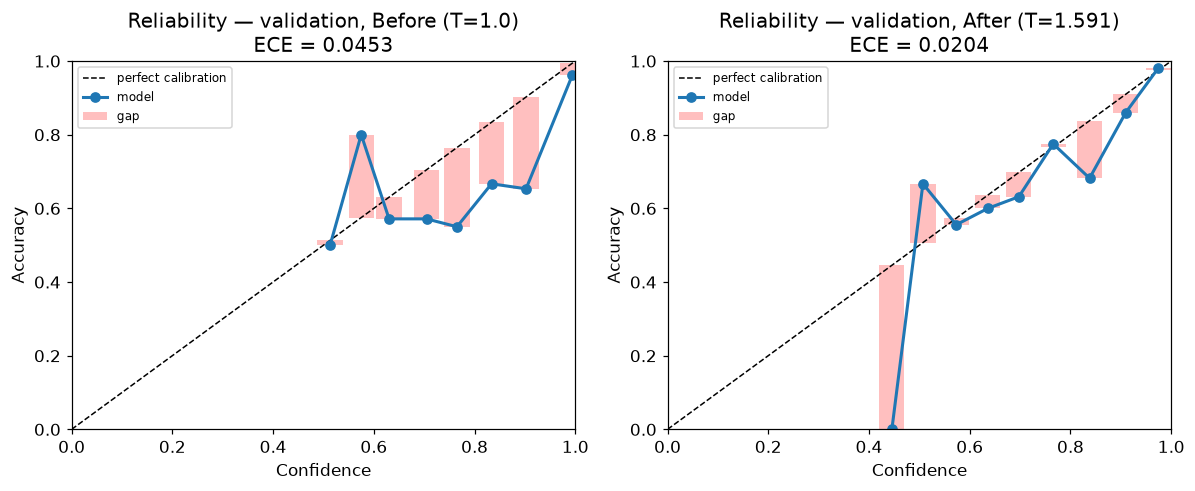

In [20]:
CALIBRATION = {"status": "NOT PERFORMED"}
TEMPERATURE = 1.0

val_texts = df.loc[val_mask, BEST_TEXT_COL].astype(str).tolist()
val_logits = bert_logits(val_texts)

def _softmax_np(z, T=1.0):
    z = np.asarray(z, dtype=float) / float(T)
    e = np.exp(z - z.max(axis=1, keepdims=True))
    return e / e.sum(axis=1, keepdims=True)

if RUN_CALIBRATION:
    zt = torch.tensor(val_logits, dtype=torch.float32)
    yt = torch.tensor(y_va, dtype=torch.long)
    log_T = torch.zeros(1, requires_grad=True)          # T = exp(log_T) keeps T > 0
    opt = torch.optim.LBFGS([log_T], lr=0.1, max_iter=200)

    def _closure():
        opt.zero_grad()
        loss = F.cross_entropy(zt / torch.exp(log_T), yt)
        loss.backward()
        return loss

    opt.step(_closure)
    T_fit = float(torch.exp(log_T).item())

    p_before = _softmax_np(val_logits, 1.0)
    p_after  = _softmax_np(val_logits, T_fit)
    ece_b, bins_b = expected_calibration_error(y_va, p_before)
    ece_a, bins_a = expected_calibration_error(y_va, p_after)
    br_b, br_a = brier_multiclass(y_va, p_before), brier_multiclass(y_va, p_after)

    apply_T = ece_a < ece_b
    TEMPERATURE = T_fit if apply_T else 1.0

    CALIBRATION = {
        "status": "DONE", "method": "temperature scaling (validation only)",
        "temperature_fitted": T_fit, "temperature_applied": TEMPERATURE,
        "applied": bool(apply_T),
        "val_ece_before": ece_b, "val_ece_after": ece_a,
        "val_brier_before": br_b, "val_brier_after": br_a,
        "n_val": int(len(y_va)),
    }
    print(json.dumps(CALIBRATION, indent=2))
    print("\nTemperature applied." if apply_T else
          "\nTemperature NOT applied — it did not improve validation ECE, so T stays 1.0.")

    # Reliability diagram, validation, before vs after
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
    for ax, bins, ece, ttl in [(axes[0], bins_b, ece_b, "Before (T=1.0)"),
                               (axes[1], bins_a, ece_a, f"After (T={T_fit:.3f})")]:
        xs = [b["avg_conf"] for b in bins]; ys = [b["accuracy"] for b in bins]
        ax.plot([0, 1], [0, 1], "k--", lw=1, label="perfect calibration")
        ax.plot(xs, ys, "o-", lw=2, label="model")
        ax.bar(xs, [y - x for x, y in zip(xs, ys)], bottom=xs, width=0.05,
               alpha=0.25, color="red", label="gap")
        ax.set_xlim(0, 1); ax.set_ylim(0, 1)
        ax.set_xlabel("Confidence"); ax.set_ylabel("Accuracy")
        ax.set_title(f"Reliability — validation, {ttl}\nECE = {ece:.4f}")
        ax.legend(loc="upper left", fontsize=8)
    plt.tight_layout()
    plt.savefig(DIRS["figures"] / "reliability_validation.png", dpi=FIG_DPI, bbox_inches="tight")
    plt.show()

    json.dump({**CALIBRATION, "bins_after": bins_a},
              open(DIRS["results"] / "calibration_validation.json", "w"), indent=2)
else:
    print("Calibration skipped; TEMPERATURE = 1.0")

# Section 15 — the single held-out test evaluation

Every hyperparameter, the representation choice, the model choice and the calibration
temperature are now frozen. This is the **first and only** time the test set is used.


[TF-IDF+LR]
  accuracy         : 0.9301
  macro_precision  : 0.9278
  macro_recall     : 0.9335
  macro_f1         : 0.9303
  weighted_f1      : 0.9301
  macro_auroc      : 0.9850
  macro_pr_auc     : 0.9728
  brier            : 0.1133
  ece              : 0.0312
  spam_fnr         : 0.0912
  per-class F1     : NORMAL=0.9327  PROMO=0.9307  SPAM=0.9276
  error types: {'NORMAL->SPAM': 23, 'PROMO->SPAM': 12, 'NORMAL->PROMO': 9, 'PROMO->NORMAL': 9, 'SPAM->NORMAL': 34, 'SPAM->PROMO': 29}

[CNN]
  accuracy         : 0.8801
  macro_precision  : 0.8762
  macro_recall     : 0.8798
  macro_f1         : 0.8779
  weighted_f1      : 0.8802
  macro_auroc      : 0.9697
  macro_pr_auc     : 0.9460
  brier            : 0.2009
  ece              : 0.0885
  spam_fnr         : 0.1230
  per-class F1     : NORMAL=0.8863  PROMO=0.8595  SPAM=0.8879
  error types: {'NORMAL->SPAM': 38, 'PROMO->SPAM': 30, 'NORMAL->PROMO': 23, 'PROMO->NORMAL': 23, 'SPAM->NORMAL': 42, 'SPAM->PROMO': 43}

[BiGRU]
  accuracy       

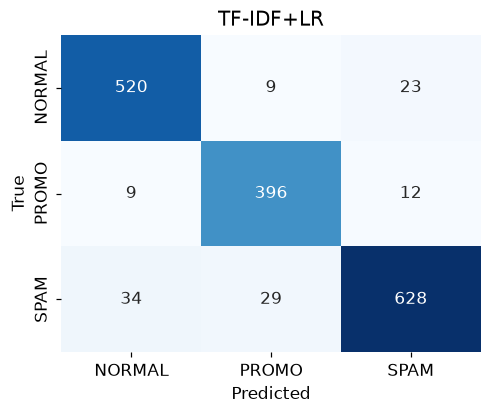

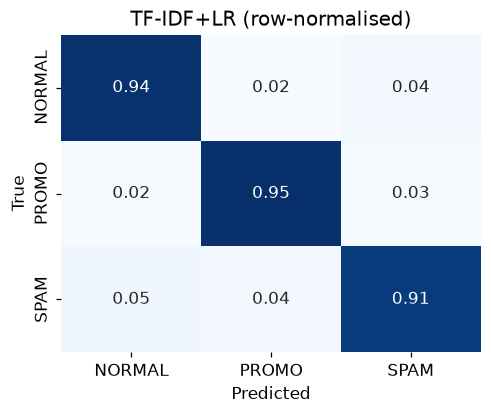


[TF-IDF+LR] classification report
              precision    recall  f1-score   support

      NORMAL     0.9236    0.9420    0.9327       552
       PROMO     0.9124    0.9496    0.9307       417
        SPAM     0.9472    0.9088    0.9276       691

    accuracy                         0.9301      1660
   macro avg     0.9278    0.9335    0.9303      1660
weighted avg     0.9306    0.9301    0.9301      1660



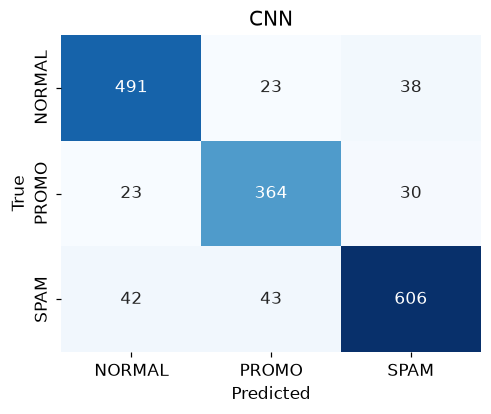

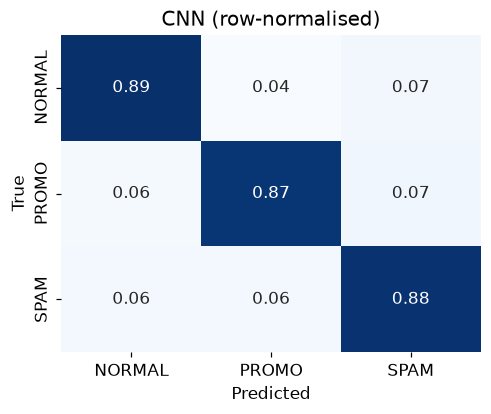


[CNN] classification report
              precision    recall  f1-score   support

      NORMAL     0.8831    0.8895    0.8863       552
       PROMO     0.8465    0.8729    0.8595       417
        SPAM     0.8991    0.8770    0.8879       691

    accuracy                         0.8801      1660
   macro avg     0.8762    0.8798    0.8779      1660
weighted avg     0.8806    0.8801    0.8802      1660



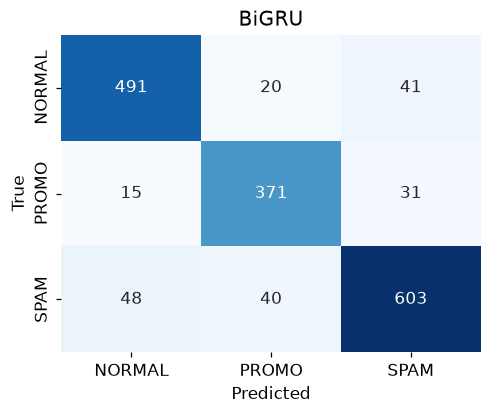

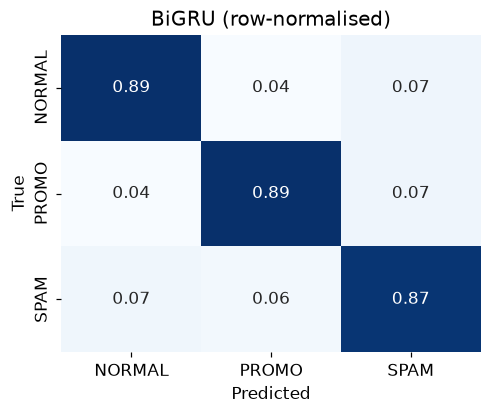


[BiGRU] classification report
              precision    recall  f1-score   support

      NORMAL     0.8863    0.8895    0.8879       552
       PROMO     0.8608    0.8897    0.8750       417
        SPAM     0.8933    0.8726    0.8829       691

    accuracy                         0.8825      1660
   macro avg     0.8801    0.8839    0.8819      1660
weighted avg     0.8828    0.8825    0.8826      1660



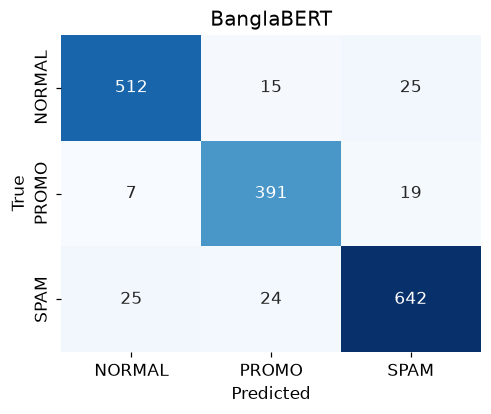

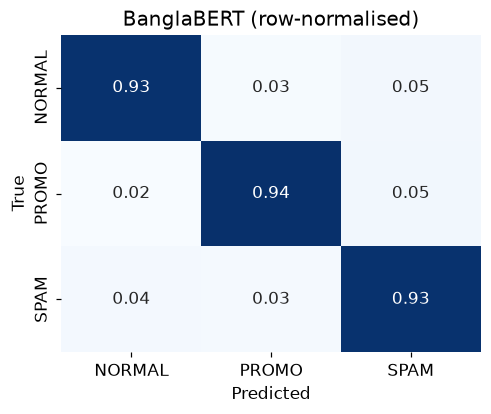


[BanglaBERT] classification report
              precision    recall  f1-score   support

      NORMAL     0.9412    0.9275    0.9343       552
       PROMO     0.9093    0.9376    0.9233       417
        SPAM     0.9359    0.9291    0.9325       691

    accuracy                         0.9307      1660
   macro avg     0.9288    0.9314    0.9300      1660
weighted avg     0.9310    0.9307    0.9308      1660



In [21]:
EFFICIENCY = {}

def _time_and_run(name, proba_fn, n_latency=200):
    t0 = time.perf_counter()
    proba = proba_fn()
    total = time.perf_counter() - t0
    n = max(1, len(proba))
    EFFICIENCY.setdefault(name, {})["latency_ms"] = (total / n) * 1000
    EFFICIENCY[name]["throughput_ps"] = n / total if total > 0 else float("nan")
    return proba

def evaluate_on_test(name, proba_fn):
    proba = _time_and_run(name, proba_fn)
    pred = proba.argmax(1)
    m = compute_metrics(y_te, pred, proba)
    m["error_types"] = error_type_counts(y_te, pred)
    m["val_macro_f1"] = VAL_RESULTS.get(name, {}).get("val_macro_f1", float("nan"))
    RESULTS.setdefault(name, {}).update(m)
    PREDICTIONS[name] = {"y_true": np.asarray(y_te), "y_pred": pred, "y_proba": proba}
    print_metrics(name, m)
    print("  error types:", m["error_types"])
    return m

if RUN_FINAL_TEST:
    if TFIDF_PATH.exists():
        evaluate_on_test("TF-IDF+LR", lambda: tfidf_predict_proba(test_mask))
    if "cnn_model" in dir():
        evaluate_on_test("CNN", lambda: seq_predict_proba(cnn_model, Xte_txt))
    if "bigru_model" in dir():
        evaluate_on_test("BiGRU", lambda: seq_predict_proba(bigru_model, Xte_txt))

    test_texts = df.loc[test_mask, BEST_TEXT_COL].astype(str).tolist()
    evaluate_on_test("BanglaBERT",
                     lambda: bert_predict_proba(test_texts, temperature=TEMPERATURE))

    print("\n" + "=" * 74)
    print("CONFUSION MATRICES AND PER-CLASS REPORTS")
    print("=" * 74)
    for name in PREDICTIONS:
        d = PREDICTIONS[name]
        plot_confusion(d["y_true"], d["y_pred"], name, normalize=False,
                       save=DIRS["figures"] / f"cm_{name}.png")
        plot_confusion(d["y_true"], d["y_pred"], name, normalize=True,
                       save=DIRS["figures"] / f"cm_{name}_norm.png")
        print(f"\n[{name}] classification report")
        print(classification_report(d["y_true"], d["y_pred"],
                                    target_names=LABEL_NAMES, digits=4, zero_division=0))

In [22]:
def _dir_mb(p):
    p = Path(p)
    return sum(f.stat().st_size for f in p.rglob("*") if f.is_file()) / 1e6 if p.exists() else float("nan")

def _file_mb(p):
    p = Path(p)
    return p.stat().st_size / 1e6 if p.exists() else float("nan")

def _count_params(m):
    return int(sum(p.numel() for p in m.parameters()))

if RESULTS:
    if "TF-IDF+LR" in RESULTS:
        d = load_tfidf_lr()
        EFFICIENCY.setdefault("TF-IDF+LR", {}).update(
            params=int(d["model"].coef_.size + d["model"].intercept_.size),
            size_mb=_file_mb(TFIDF_PATH),
            train_time_s=globals().get("TFIDF_TRAIN_TIME", float("nan")))
    if "CNN" in RESULTS:
        EFFICIENCY.setdefault("CNN", {}).update(
            params=_count_params(cnn_model), size_mb=_file_mb(CNN_PATH),
            train_time_s=globals().get("CNN_TRAIN_TIME", float("nan")))
    if "BiGRU" in RESULTS:
        EFFICIENCY.setdefault("BiGRU", {}).update(
            params=_count_params(bigru_model), size_mb=_file_mb(BIGRU_PATH),
            train_time_s=globals().get("BIGRU_TRAIN_TIME", float("nan")))
    if "BanglaBERT" in RESULTS:
        EFFICIENCY.setdefault("BanglaBERT", {}).update(
            params=_count_params(clf_model), size_mb=_dir_mb(BERT_DIR),
            train_time_s=globals().get("BERT_TRAIN_TIME", float("nan")))

    for k, v in EFFICIENCY.items():
        RESULTS.setdefault(k, {}).update(v)

    cols = ["accuracy", "macro_precision", "macro_recall", "macro_f1", "weighted_f1",
            "f1_NORMAL", "f1_PROMO", "f1_SPAM", "macro_auroc", "macro_pr_auc",
            "brier", "ece", "spam_fnr", "val_macro_f1",
            "params", "size_mb", "train_time_s", "latency_ms", "throughput_ps"]
    comp_df = pd.DataFrame(RESULTS).T
    comp_df = comp_df[[c for c in cols if c in comp_df.columns]]
    comp_df = comp_df.sort_values("macro_f1", ascending=False)
    comp_df.index.name = "Model"
    pd.set_option("display.width", 220, "display.max_columns", 60,
                  "display.float_format", lambda v: f"{v:,.4f}")
    print(comp_df.to_string())
    comp_df.to_csv(DIRS["results"] / "model_comparison.csv")
else:
    comp_df = pd.DataFrame()
    print("No results — run the test evaluation first.")

           accuracy macro_precision macro_recall macro_f1 weighted_f1 f1_NORMAL f1_PROMO f1_SPAM macro_auroc macro_pr_auc  brier    ece spam_fnr val_macro_f1     params  size_mb train_time_s latency_ms throughput_ps
Model                                                                                                                                                                                                                  
TF-IDF+LR    0.9301          0.9278       0.9335   0.9303      0.9301    0.9327   0.9307  0.9276      0.9850       0.9728 0.1133 0.0312   0.0912       0.9232     405324   8.6051     124.1096     0.4457    2,243.5185
BanglaBERT   0.9307          0.9288       0.9314   0.9300      0.9308    0.9343   0.9233  0.9325      0.9839       0.9739 0.1144 0.0127   0.0709       0.9299  110619651 443.5365     221.7129     0.5791    1,726.7591
BiGRU        0.8825          0.8801       0.8839   0.8819      0.8826    0.8879   0.8750  0.8829      0.9698       0.9454 0.1965 0.0796 

### 16. McNemar's test (pairwise, Bonferroni-corrected) and test-set calibration

In [23]:
from itertools import combinations
try:
    from statsmodels.stats.contingency_tables import mcnemar as sm_mcnemar
    HAVE_SM = True
except Exception:
    HAVE_SM = False
    print("statsmodels not found -> exact binomial fallback")

def mcnemar_pair(y_true, pa, pb):
    ca, cb = (pa == y_true), (pb == y_true)
    n01 = int((~ca & cb).sum()); n10 = int((ca & ~cb).sum())
    if HAVE_SM:
        res = sm_mcnemar([[0, n01], [n10, 0]], exact=(n01 + n10) < 25,
                         correction=(n01 + n10) >= 25)
        return float(res.statistic), float(res.pvalue), n01, n10
    from scipy.stats import binomtest
    n = n01 + n10
    p = binomtest(min(n01, n10), n, 0.5).pvalue if n > 0 else 1.0
    return float(min(n01, n10)), float(min(1.0, p)), n01, n10

mcnemar_df = pd.DataFrame()
if RUN_MCNEMAR and len(PREDICTIONS) > 1:
    pairs = list(combinations(PREDICTIONS.keys(), 2))
    rows = []
    for a, b in pairs:
        st, p, n01, n10 = mcnemar_pair(np.asarray(y_te), PREDICTIONS[a]["y_pred"],
                                       PREDICTIONS[b]["y_pred"])
        rows.append({"pair": f"{a} vs {b}", "statistic": st, "p_value": p,
                     "p_bonferroni": min(1.0, p * len(pairs)),
                     "sig_0.05_bonf": (p * len(pairs)) < 0.05,
                     f"only_{a}_correct": n10, f"only_{b}_correct": n01})
    mcnemar_df = pd.DataFrame(rows)
    print(mcnemar_df.to_string(index=False))
    print(f"\nBonferroni correction factor (number of pairs) = {len(pairs)}")
    mcnemar_df.to_csv(DIRS["results"] / "mcnemar.csv", index=False)

statsmodels not found -> exact binomial fallback
                   pair  statistic  p_value  p_bonferroni  sig_0.05_bonf  only_TF-IDF+LR_correct  only_CNN_correct  only_BiGRU_correct  only_BanglaBERT_correct
       TF-IDF+LR vs CNN    30.0000   0.0000        0.0000           True                113.0000           30.0000                 NaN                      NaN
     TF-IDF+LR vs BiGRU    29.0000   0.0000        0.0000           True                108.0000               NaN             29.0000                      NaN
TF-IDF+LR vs BanglaBERT    39.0000   1.0000        1.0000          False                 39.0000               NaN                 NaN                  40.0000
           CNN vs BiGRU    71.0000   0.8040        1.0000          False                     NaN           71.0000             75.0000                      NaN
      CNN vs BanglaBERT    36.0000   0.0000        0.0000           True                     NaN           36.0000                 NaN                 

BanglaBERT on TEST — ECE = 0.0127 | Brier = 0.1144 | T applied = 1.5907
Mean confidence: correct 0.9488 | incorrect 0.8151


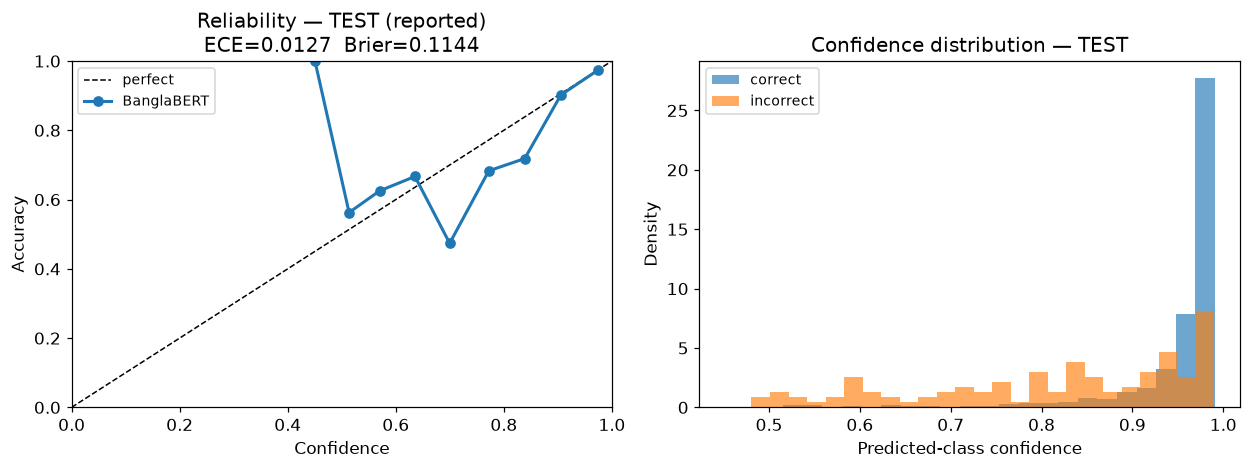

In [24]:
# Test-set calibration is REPORTED here (never used to fit anything).
if "BanglaBERT" in PREDICTIONS:
    p_te = PREDICTIONS["BanglaBERT"]["y_proba"]
    ece_te, bins_te = expected_calibration_error(y_te, p_te)
    br_te = brier_multiclass(y_te, p_te)
    conf = p_te.max(1); correct = (p_te.argmax(1) == np.asarray(y_te))

    print(f"BanglaBERT on TEST — ECE = {ece_te:.4f} | Brier = {br_te:.4f} "
          f"| T applied = {TEMPERATURE:.4f}")
    print(f"Mean confidence: correct {conf[correct].mean():.4f} | "
          f"incorrect {conf[~correct].mean():.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4))
    xs = [b["avg_conf"] for b in bins_te]; ys = [b["accuracy"] for b in bins_te]
    axes[0].plot([0, 1], [0, 1], "k--", lw=1, label="perfect")
    axes[0].plot(xs, ys, "o-", lw=2, label="BanglaBERT")
    axes[0].set_xlabel("Confidence"); axes[0].set_ylabel("Accuracy")
    axes[0].set_title(f"Reliability — TEST (reported)\nECE={ece_te:.4f}  Brier={br_te:.4f}")
    axes[0].legend(fontsize=9); axes[0].set_xlim(0, 1); axes[0].set_ylim(0, 1)

    axes[1].hist(conf[correct], bins=25, alpha=0.65, label="correct", density=True)
    axes[1].hist(conf[~correct], bins=25, alpha=0.65, label="incorrect", density=True)
    axes[1].set_xlabel("Predicted-class confidence"); axes[1].set_ylabel("Density")
    axes[1].set_title("Confidence distribution — TEST"); axes[1].legend(fontsize=9)
    plt.tight_layout()
    plt.savefig(DIRS["figures"] / "calibration_test.png", dpi=FIG_DPI, bbox_inches="tight")
    plt.show()

    CALIBRATION_TEST = {"ece": ece_te, "brier": br_te,
                        "mean_conf_correct": float(conf[correct].mean()),
                        "mean_conf_incorrect": float(conf[~correct].mean()),
                        "bins": bins_te}
    json.dump(CALIBRATION_TEST, open(DIRS["results"] / "calibration_test.json", "w"), indent=2)

### 17. Comparison figures (750 DPI, saved to `smishing_experiment/figures/`)

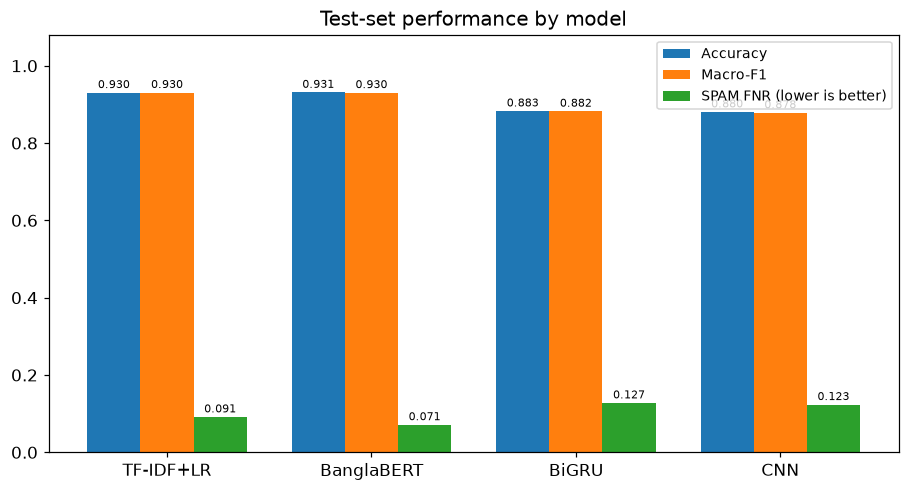

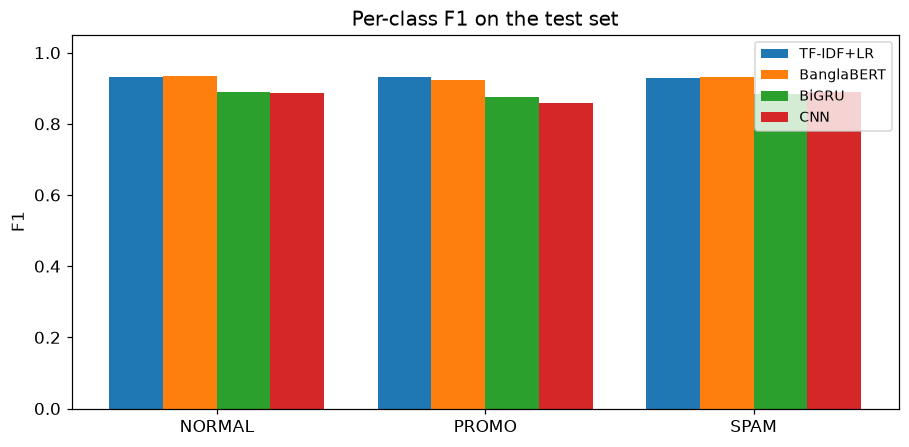

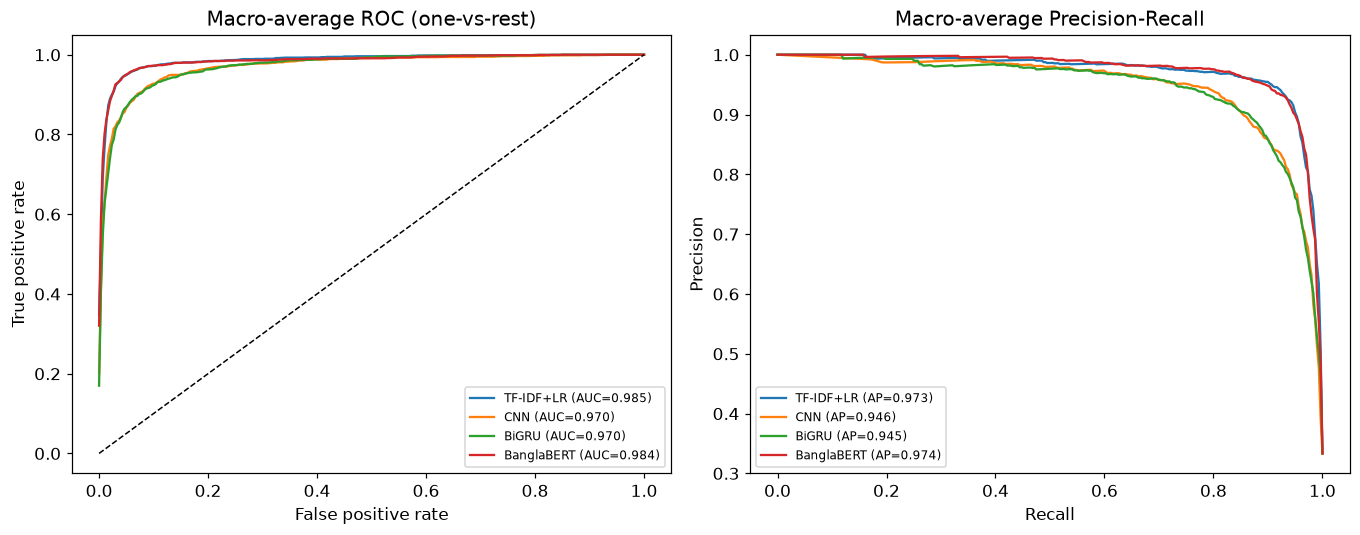

In [25]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve
FIGD = DIRS["figures"]

if RESULTS:
    order = sorted(RESULTS.keys(), key=lambda k: -RESULTS[k].get("macro_f1", 0))
    acc = [RESULTS[m].get("accuracy", np.nan) for m in order]
    mf1 = [RESULTS[m].get("macro_f1", np.nan) for m in order]
    fnr = [RESULTS[m].get("spam_fnr", np.nan) for m in order]
    x = np.arange(len(order)); w = 0.26
    fig, ax = plt.subplots(figsize=(8.4, 4.6))
    for off, vals, lab in [(-w, acc, "Accuracy"), (0, mf1, "Macro-F1"),
                           (w, fnr, "SPAM FNR (lower is better)")]:
        bars = ax.bar(x + off, vals, w, label=lab)
        for b, v in zip(bars, vals):
            if v == v:
                ax.text(b.get_x() + b.get_width() / 2, v + 0.012, f"{v:.3f}",
                        ha="center", fontsize=7.5)
    ax.set_xticks(x); ax.set_xticklabels(order); ax.set_ylim(0, 1.08)
    ax.set_title("Test-set performance by model"); ax.legend(fontsize=9)
    plt.tight_layout(); plt.savefig(FIGD / "model_comparison.png", dpi=FIG_DPI); plt.show()

    # Per-class F1
    fig, ax = plt.subplots(figsize=(8.4, 4.2))
    w2 = 0.8 / max(1, len(order))
    for j, m in enumerate(order):
        vals = [RESULTS[m].get(f"f1_{c}", np.nan) for c in LABEL_NAMES]
        ax.bar(np.arange(3) + j * w2 - 0.4 + w2 / 2, vals, w2, label=m)
    ax.set_xticks(range(3)); ax.set_xticklabels(LABEL_NAMES)
    ax.set_ylabel("F1"); ax.set_ylim(0, 1.05)
    ax.set_title("Per-class F1 on the test set"); ax.legend(fontsize=9)
    plt.tight_layout(); plt.savefig(FIGD / "per_class_f1.png", dpi=FIG_DPI); plt.show()

if PREDICTIONS:
    fig, axes = plt.subplots(1, 2, figsize=(12.5, 5))
    grid = np.linspace(0, 1, 300)
    for m, d in PREDICTIONS.items():
        Yb = label_binarize(d["y_true"], classes=list(range(NUM_CLASSES)))
        pr = np.asarray(d["y_proba"])
        tprs = []
        for c in range(NUM_CLASSES):
            fpr, tpr, _ = roc_curve(Yb[:, c], pr[:, c])
            tprs.append(np.interp(grid, fpr, tpr))
        mt = np.mean(tprs, axis=0)
        axes[0].plot(grid, mt, label=f"{m} (AUC={auc(grid, mt):.3f})")
        precs = []
        for c in range(NUM_CLASSES):
            p_, r_, _ = precision_recall_curve(Yb[:, c], pr[:, c])
            precs.append(np.interp(grid, r_[::-1], p_[::-1]))
        mp = np.mean(precs, axis=0)
        axes[1].plot(grid, mp, label=f"{m} (AP={RESULTS[m].get('macro_pr_auc', np.nan):.3f})")
    axes[0].plot([0, 1], [0, 1], "k--", lw=1)
    axes[0].set_xlabel("False positive rate"); axes[0].set_ylabel("True positive rate")
    axes[0].set_title("Macro-average ROC (one-vs-rest)"); axes[0].legend(fontsize=8)
    axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
    axes[1].set_title("Macro-average Precision-Recall"); axes[1].legend(fontsize=8)
    plt.tight_layout(); plt.savefig(FIGD / "roc_pr_curves.png", dpi=FIG_DPI); plt.show()

### 18. Save the deployment classifier

`deployment/classifier/` holds weights, tokenizer, config, label mapping and the
calibration parameter — everything needed to load and serve the model with a
probability-like confidence score.

In [26]:
CLF_DEPLOY = DEPLOY / "classifier"
(CLF_DEPLOY / "model").mkdir(parents=True, exist_ok=True)
(CLF_DEPLOY / "tokenizer").mkdir(parents=True, exist_ok=True)

clf_model.save_pretrained(CLF_DEPLOY / "model")
clf_tok.save_pretrained(CLF_DEPLOY / "tokenizer")

json.dump({"label2id": LABEL2ID, "id2label": {str(k): v for k, v in ID2LABEL.items()},
           "label_names": LABEL_NAMES},
          open(CLF_DEPLOY / "label_mapping.json", "w"), indent=2, ensure_ascii=False)

json.dump({"method": "temperature_scaling",
           "temperature": float(TEMPERATURE),
           "fitted_on": "validation split only",
           "fitted_value": float(CALIBRATION.get("temperature_fitted", 1.0)),
           "applied": bool(CALIBRATION.get("applied", False)),
           "val_ece_before": CALIBRATION.get("val_ece_before"),
           "val_ece_after": CALIBRATION.get("val_ece_after"),
           "usage": "probs = softmax(logits / temperature)"},
          open(CLF_DEPLOY / "calibration.json", "w"), indent=2)

json.dump({"base_checkpoint": BANGLABERT_ID, "text_column": BEST_TEXT_COL,
           "max_length": int(MAX_LEN), "seed": SEED, "num_classes": NUM_CLASSES,
           "hyperparameters": BEST_BERT_CFG,
           "normalizer": NORMALIZER_KIND,
           "training": "full fine-tuning (no LoRA)",
           "val_macro_f1": VAL_RESULTS.get("BanglaBERT", {}).get("val_macro_f1"),
           "test_macro_f1": RESULTS.get("BanglaBERT", {}).get("macro_f1")},
          open(CLF_DEPLOY / "config.json", "w"), indent=2, ensure_ascii=False)

def classify_sms(text: str) -> dict:
    """Deployment entry point: {'label': 'SPAM', 'confidence': 0.94}."""
    t = normalize_bn(text)
    p = bert_predict_proba([t], temperature=TEMPERATURE)[0]
    i = int(p.argmax())
    return {"label": ID2LABEL[i], "confidence": round(float(p[i]), 4),
            "probabilities": {ID2LABEL[j]: round(float(p[j]), 4) for j in range(NUM_CLASSES)}}

print("Saved classifier to", CLF_DEPLOY.resolve())
_demo = df.loc[test_mask, BEST_TEXT_COL].iloc[0]
print("\nDemo:", _demo[:80])
print(json.dumps({k: v for k, v in classify_sms(_demo).items() if k != "probabilities"},
                 indent=2))

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved classifier to C:\Users\mahmu\smishing-project\deployment\classifier

Demo: "২৯ মে আন্তর্জাতিক জাতিসংঘ শান্তিরক্ষী দিবস। শান্তি মিশনে বাংলাদেশের ৩৭ তম বর্ষপ
{
  "label": "NORMAL",
  "confidence": 0.9873
}


# PART 3 — XAI evidence

### 19. Diagnosing the negative `comprehensive_mean`

In [27]:
from captum.attr import LayerIntegratedGradients

XAI_STEPS = 32 if not QUICK_TEST else 8
_EMB_LAYER = clf_model.get_input_embeddings()

def encode_xai(text, max_length=None):
    """Encode once; everything downstream uses THIS encoding."""
    max_length = max_length or MAX_LEN
    enc = clf_tok(text, truncation=True, max_length=max_length,
                  return_offsets_mapping=clf_tok.is_fast, return_tensors="pt")
    offsets = enc.pop("offset_mapping")[0].tolist() if clf_tok.is_fast else None
    return enc, offsets

def _special_positions(ids):
    sm = clf_tok.get_special_tokens_mask(ids, already_has_special_tokens=True)
    return set(i for i, v in enumerate(sm) if v == 1)

@torch.no_grad()
def _proba_from_ids(ids_list, temperature=None):
    """Batch-score a list of token-id lists. Perturbation happens HERE, in id space."""
    temperature = TEMPERATURE if temperature is None else temperature
    if not ids_list:
        return np.zeros((0, NUM_CLASSES))
    L = max(len(x) for x in ids_list)
    pad = clf_tok.pad_token_id
    ids = torch.full((len(ids_list), L), pad, dtype=torch.long)
    att = torch.zeros((len(ids_list), L), dtype=torch.long)
    for i, x in enumerate(ids_list):
        ids[i, :len(x)] = torch.tensor(x, dtype=torch.long)
        att[i, :len(x)] = 1
    out = []
    for i in range(0, len(ids_list), 64):
        logits = clf_model(input_ids=ids[i:i + 64].to(DEVICE),
                           attention_mask=att[i:i + 64].to(DEVICE)).logits.float().cpu().numpy()
        out.append(logits)
    lg = np.concatenate(out, axis=0) / float(temperature)
    e = np.exp(lg - lg.max(axis=1, keepdims=True))
    return e / e.sum(axis=1, keepdims=True)

def ig_attributions(text, target=None, steps=None):
    """Layer Integrated Gradients on the embedding layer.

    Baseline keeps [CLS]/[SEP] in place and replaces every content token with [PAD] —
    the standard reference input for a classifier, and the same shape the model sees.
    Returns SIGNED per-position attribution toward the target class.
    """
    steps = steps or XAI_STEPS
    clf_model.eval()
    enc, offsets = encode_xai(text)
    input_ids = enc["input_ids"].to(DEVICE)
    attn      = enc["attention_mask"].to(DEVICE)
    ids_list  = input_ids[0].cpu().tolist()
    specials  = _special_positions(ids_list)

    p_full = _proba_from_ids([ids_list])[0]
    tgt = int(p_full.argmax()) if target is None else int(target)

    base = input_ids.clone()
    for i in range(base.shape[1]):
        if i not in specials:
            base[0, i] = clf_tok.pad_token_id

    def fwd(ids, mask):
        return clf_model(input_ids=ids, attention_mask=mask).logits

    lig = LayerIntegratedGradients(fwd, _EMB_LAYER)
    att = lig.attribute(inputs=input_ids, baselines=base,
                        additional_forward_args=(attn,), target=tgt,
                        n_steps=steps, internal_batch_size=8)
    scores = att.sum(dim=-1).squeeze(0).detach().float().cpu().numpy()
    # L2-normalise so magnitudes are comparable across messages
    denom = np.linalg.norm(scores) + 1e-12
    scores = scores / denom
    return {"ids": ids_list, "offsets": offsets, "specials": specials,
            "scores": scores, "proba": p_full, "target": tgt}

def loo_attributions(text, target=None):
    """Leave-one-out occlusion: drop each content position and measure the drop in
    p(target). Slower than IG but perturbation-based, so it is the natural cross-check
    for a perturbation-based faithfulness metric."""
    enc, offsets = encode_xai(text)
    ids_list = enc["input_ids"][0].tolist()
    specials = _special_positions(ids_list)
    p_full = _proba_from_ids([ids_list])[0]
    tgt = int(p_full.argmax()) if target is None else int(target)

    content = [i for i in range(len(ids_list)) if i not in specials]
    variants = [[t for j, t in enumerate(ids_list) if j != i] for i in content]
    scores = np.zeros(len(ids_list), dtype=float)
    if variants:
        probs = _proba_from_ids(variants)
        for pos, pr in zip(content, probs):
            scores[pos] = float(p_full[tgt] - pr[tgt])   # positive => token supported tgt
    return {"ids": ids_list, "offsets": offsets, "specials": specials,
            "scores": scores, "proba": p_full, "target": tgt}

print(f"XAI core ready. IG steps = {XAI_STEPS}. Fast tokenizer (offsets): {clf_tok.is_fast}")

XAI core ready. IG steps = 32. Fast tokenizer (offsets): True


### 20. From attribution to typed, verified evidence

Sub-word positions are grouped into **word spans using `offset_mapping`**, so every piece
of evidence is a literal substring of the SMS — `sms[start:end]` reproduces it exactly.
That is the mechanical guarantee behind "the evidence must actually exist in the SMS".

Each span is then typed with a lexicon + regex layer. Two rules matter for the research
question:

* A URL, price, phone number or USSD code is **never** by itself treated as malicious.
  The type is assigned from surface form; whether it is *suspicious* depends on the
  predicted class and, for URLs, on the domain.
* For PROMO and NORMAL the same surface features are described with neutral wording
  (offer, package, dial code), because a legitimate telecom promotion legitimately
  contains all of them.

In [28]:
# ------------------------- evidence type lexicon ---------------------------
URL_RE   = re.compile(r"(https?://\S+|www\.\S+|\b[a-z0-9\-]+\.(?:com|net|org|xyz|top|info|link|ly|bd|gov\.bd|co)\b\S*)", re.I)
USSD_RE  = re.compile(r"\*[\d\*#]{2,}#")
PHONE_RE = re.compile(r"(\+?880\d{8,10}|\b01[3-9]\d{8}\b|\b\d{11}\b)")
MONEY_RE = re.compile(r"(৳\s?[\d০-৯,.]+|[\d০-৯,.]+\s?(?:টাকা|tk|taka|৳)|moneytoken)", re.I)
NUM_RE   = re.compile(r"^[\d০-৯,.%]+$")

SHORTENERS = {"bit.ly", "t.ly", "tinyurl.com", "cutt.ly", "rb.gy", "is.gd", "shorturl.at",
              "t.co", "goo.gl", "ow.ly", "rebrand.ly", "shorte.st", "adf.ly", "bit.do"}
TRUSTED_TLD = (".gov.bd", ".edu.bd", ".org.bd")

LEXICON = {
    "urgency": ["এখনই", "এখনি", "দ্রুত", "তাড়াতাড়ি", "শীঘ্রই", "আজই", "সীমিত", "শেষ",
                 "সুযোগ", "অবিলম্বে", "জরুরি", "তৎক্ষণাৎ", "তাৎক্ষণিক", "মেয়াদ", "শেষদিন",
                 "hurry", "urgent", "now", "immediately", "limited", "last", "expire", "today"],
    "sensitive_info_request": ["পিন", "পাসওয়ার্ড", "ওটিপি", "গোপন", "কোড", "যাচাই", "ভেরিফাই",
                 "লগইন", "লগ-ইন", "এনআইডি", "জাতীয়", "পরিচয়পত্র", "অ্যাকাউন্ট", "একাউন্ট",
                 "otp", "pin", "password", "cvv", "nid", "verify", "login", "account", "confirm"],
    "financial_request": ["টাকা", "পাঠান", "ট্রান্সফার", "পেমেন্ট", "পরিশোধ", "জমা", "রিচার্জ",
                 "বিকাশ", "নগদ", "রকেট", "উপায়", "ব্যালেন্স", "লেনদেন",
                 "bkash", "nagad", "rocket", "upay", "send", "transfer", "payment", "pay", "balance"],
    "impersonation": ["ব্যাংক", "কর্তৃপক্ষ", "সরকার", "মন্ত্রণালয়", "পুলিশ", "অফিসিয়াল",
                 "কাস্টমার", "কেয়ার", "হেল্পলাইন", "প্রশাসন", "কমিশন",
                 "bank", "official", "authority", "government", "police", "customer", "care", "support"],
    "reward_claim": ["পুরস্কার", "জিতেছেন", "জিতুন", "বিজয়ী", "লটারি", "ফ্রি", "উপহার",
                 "বোনাস", "লাখ", "কোটি", "ক্যাশব্যাক", "নগদ_পুরস্কার",
                 "prize", "win", "winner", "won", "lottery", "free", "gift", "bonus", "reward", "cashback"],
    "threat_warning": ["বন্ধ", "ব্লক", "স্থগিত", "বাতিল", "জরিমানা", "শাস্তি", "মামলা",
                 "সতর্ক", "সাসপেন্ড", "নিষ্ক্রিয়", "ঝুঁকি", "সমস্যা",
                 "block", "blocked", "suspend", "suspended", "deactivate", "penalty",
                 "warning", "risk", "problem", "closed"],
    "suspicious_action": ["ক্লিক", "চাপুন", "ডাউনলোড", "লিংক", "লিঙ্ক", "ভিজিট", "নিবন্ধন",
                 "রেজিস্ট্রেশন", "পূরণ", "ফরম", "আপডেট", "ইনস্টল",
                 "click", "tap", "download", "link", "visit", "register", "update", "install", "form"],
    "promo_offer": ["অফার", "প্যাক", "প্যাকেজ", "জিবি", "এমবি", "মিনিট", "বান্ডেল",
                 "ইন্টারনেট", "ডায়াল", "কিনতে", "নিতে", "রেট", "ছাড়", "ডিসকাউন্ট",
                 "offer", "pack", "package", "bundle", "internet", "dial", "discount", "rate"],
}

EVIDENCE_TYPE_BN = {
    "suspicious_url": "সন্দেহজনক লিংক",
    "url": "ওয়েব লিংক",
    "urgency": "তাড়াহুড়ার ভাষা",
    "sensitive_info_request": "গোপন তথ্য চাওয়া",
    "financial_request": "আর্থিক লেনদেনের অনুরোধ",
    "impersonation": "পরিচয় ভাঁড়ানোর ইঙ্গিত",
    "reward_claim": "পুরস্কার বা উপহারের দাবি",
    "threat_warning": "ভয় দেখানো বা সতর্কবার্তা",
    "suspicious_action": "নির্দিষ্ট পদক্ষেপ নিতে বলা",
    "phone_number": "ফোন নম্বর",
    "ussd_code": "ডায়াল কোড",
    "money_amount": "টাকার অঙ্ক",
    "promo_offer": "অফার বা প্যাকেজের তথ্য",
    "linguistic_indicator": "ভাষাগত ইঙ্গিত",
}

# Types that are ONLY warning signs when the model predicted SPAM. For PROMO/NORMAL they
# are ordinary content and are described neutrally.
NEUTRAL_FOR_NON_SPAM = {"phone_number", "ussd_code", "money_amount", "promo_offer", "url"}
ALWAYS_NEUTRAL       = {"promo_offer"}

def _domain_of(u):
    m = re.search(r"(?:https?://)?(?:www\.)?([^/\s]+)", u.lower())
    return m.group(1) if m else ""

def classify_span(span_text, full_text):
    """Assign a surface type to a span. Purely descriptive — not a verdict."""
    s = span_text.strip()
    low = s.lower()
    if not s:
        return None
    if URL_RE.search(s) or "urltoken" in low:
        dom = _domain_of(s)
        if dom in SHORTENERS or (dom and not dom.endswith(TRUSTED_TLD) and len(dom.split(".")) > 3):
            return "suspicious_url"
        return "suspicious_url" if dom in SHORTENERS else "url"
    if USSD_RE.search(s) or "ussdtoken" in low:
        return "ussd_code"
    if PHONE_RE.search(s) or "phonetoken" in low:
        return "phone_number"
    if MONEY_RE.search(s) or "moneytoken" in low:
        return "money_amount"
    for t, words in LEXICON.items():
        for w in words:
            if w and (w in low or w in s):
                return t
    if NUM_RE.match(s) or low == "numtoken":
        return None          # a bare number alone is not evidence
    return "linguistic_indicator"

def group_positions_to_spans(text, offsets, scores, specials):
    """Merge sub-word positions into whitespace-delimited word spans of the ORIGINAL text.
    Attributions of the merged positions are summed."""
    spans = []
    cur = None
    for i, (a, b) in enumerate(offsets or []):
        if i in specials or b <= a:
            continue
        piece_start, piece_end = int(a), int(b)
        if cur is not None and piece_start <= cur["end"] and \
           not text[cur["end"]:piece_start].strip() and \
           " " not in text[cur["end"]:piece_start]:
            cur["end"] = max(cur["end"], piece_end)
            cur["score"] += float(scores[i])
            cur["positions"].append(i)
        else:
            if cur is not None:
                spans.append(cur)
            cur = {"start": piece_start, "end": piece_end, "score": float(scores[i]),
                   "positions": [i]}
    if cur is not None:
        spans.append(cur)
    for sp in spans:
        sp["text"] = text[sp["start"]:sp["end"]]
    return spans

def _fallback_spans(text, ids, scores, specials):
    """If the tokenizer is not fast (no offsets), fall back to decoding each position."""
    spans = []
    for i, tid in enumerate(ids):
        if i in specials:
            continue
        piece = clf_tok.convert_ids_to_tokens([tid])[0]
        piece = piece[2:] if piece.startswith("##") else piece
        st = text.find(piece)
        spans.append({"start": st, "end": st + len(piece) if st >= 0 else -1,
                      "score": float(scores[i]), "positions": [i],
                      "text": piece if st < 0 else text[st:st + len(piece)]})
    return spans
print("Evidence typing layer ready:", len(EVIDENCE_TYPE_BN), "types.")

Evidence typing layer ready: 14 types.


In [29]:
def explain_sms(text, topk=6, method="ig", min_share=0.02):
    """SMS -> predicted label + calibrated confidence -> verified typed evidence.

    Evidence is ranked by SIGNED attribution toward the predicted class (the fix for
    Bug B). Only spans with positive support are kept: a span that argues against the
    prediction is not evidence FOR it.
    """
    text = normalize_bn(text)
    A = ig_attributions(text) if method == "ig" else loo_attributions(text)
    scores, ids, specials, offsets = A["scores"], A["ids"], A["specials"], A["offsets"]
    proba, tgt = A["proba"], A["target"]

    spans = group_positions_to_spans(text, offsets, scores, specials) if offsets \
            else _fallback_spans(text, ids, scores, specials)

    pos = [s for s in spans if s["score"] > 0 and s["text"].strip()]
    total = sum(s["score"] for s in pos) or 1.0
    pos.sort(key=lambda s: -s["score"])

    evidence = []
    for s in pos:
        if len(evidence) >= topk:
            break
        share = s["score"] / total
        if share < min_share and evidence:
            continue
        etype = classify_span(s["text"], text)
        if etype is None:
            continue
        # verification: the span must literally be in the SMS
        if s["start"] >= 0 and text[s["start"]:s["end"]] != s["text"]:
            continue
        evidence.append({
            "text": s["text"],
            "type": etype,
            "type_bn": EVIDENCE_TYPE_BN.get(etype, etype),
            "importance": round(float(share), 4),
            "raw_attribution": round(float(s["score"]), 6),
            "char_start": int(s["start"]), "char_end": int(s["end"]),
            "token_positions": s["positions"],
        })

    return {
        "sms": text,
        "predicted_label": ID2LABEL[tgt],
        "predicted_id": tgt,
        "confidence": round(float(proba[tgt]), 4),
        "probabilities": {ID2LABEL[j]: round(float(proba[j]), 4) for j in range(NUM_CLASSES)},
        "evidence": evidence,
        "method": ("Integrated Gradients (BanglaBERT embeddings, signed, token-id space)"
                   if method == "ig" else "Leave-one-out occlusion (token-id space)"),
        "_attr": {"scores": scores.tolist(), "ids": ids,
                  "specials": sorted(specials), "target": tgt,
                  "p_full": proba.tolist()},
    }

def show_explanation(text, topk=6, method="ig"):
    r = explain_sms(text, topk=topk, method=method)
    print("-" * 74)
    disp = r["sms"][:95] + ("..." if len(r["sms"]) > 95 else "")
    print("SMS       :", disp)
    print(f"Prediction: {r['predicted_label']}    Confidence: {r['confidence']*100:.2f}%")
    print(f"Method    : {r['method']}")
    print("Verified evidence (supports the prediction, exists in the SMS):")
    if not r["evidence"]:
        print("   (no span passed the support threshold)")
    for e in r["evidence"]:
        assert r["sms"][e["char_start"]:e["char_end"]] == e["text"]
        print(f"   • {e['text'][:26]:<28} {e['type']:<24} importance={e['importance']:.3f}")
    return r

if RUN_XAI:
    print("XAI demo — one message per class from the TEST split\n")
    for cid in [SPAM_ID, PROMO_ID, NORMAL_ID]:
        idx = [i for i in df.index[test_mask] if df.loc[i, COL_LABEL_ID] == cid][:2]
        for i in idx:
            show_explanation(str(df.loc[i, BEST_TEXT_COL]))

XAI demo — one message per class from the TEST split

--------------------------------------------------------------------------
SMS       : [Pathao] আমরা Techland BD থেকে আপনার পণ্য XXXXXFKER টি সংগ্রহ করেছি। ট্র্যাক করুন https://ptho....
Prediction: NORMAL    Confidence: 95.45%
Method    : Integrated Gradients (BanglaBERT embeddings, signed, token-id space)
Verified evidence (supports the prediction, exists in the SMS):
   • https://ptho.app/XXXXX       url                      importance=0.316
   • [Pathao]                     linguistic_indicator     importance=0.257
   • Techland                     linguistic_indicator     importance=0.239
   • BD                           linguistic_indicator     importance=0.089
   • করেছি।                       linguistic_indicator     importance=0.054
   • আমরা                         linguistic_indicator     importance=0.040
--------------------------------------------------------------------------
SMS       : ৳৯৯+অর্ডারে গিফট! কোড: WOW ডিম 

### 21. Reproducing the old bug next to the fixed metric

This cell runs the **previous** implementation and the **corrected** one on the same
messages, so the dissertation can state the cause with evidence rather than assertion.
`old_string_match_removal_rate` is the share of whitespace tokens the old code actually
removed — if it is near zero, Bug A is confirmed directly.

In [30]:
def _merge_subwords_legacy(tokens, scores):
    """The exact merging the previous notebook used, kept for the diagnosis."""
    words, ws, cur, cur_s = [], [], None, 0.0
    for tok, sc in zip(tokens, scores):
        if tok in ("[CLS]", "[SEP]", "[PAD]", "[MASK]", "[UNK]"):
            continue
        piece, cont = tok, False
        if piece.startswith("##"):
            piece, cont = piece[2:], True
        if cont and cur is not None:
            cur += piece; cur_s += float(sc)
        else:
            if cur is not None:
                words.append(cur); ws.append(cur_s)
            cur, cur_s = piece, float(sc)
    if cur is not None:
        words.append(cur); ws.append(cur_s)
    return words, ws

DIAGNOSIS = {"status": "SKIPPED"}
if RUN_XAI and RUN_XAI_FAITHFULNESS:
    idxs = list(df.index[test_mask])[:60 if not QUICK_TEST else 12]
    old_comp, new_comp = [], []
    removal_rates, abs_neg_share = [], []

    for i in idxs:
        txt = normalize_bn(str(df.loc[i, BEST_TEXT_COL]))
        toks_ws = txt.split()
        if len(toks_ws) < 3:
            continue
        A = ig_attributions(txt)
        ids, scores, specials = A["ids"], A["scores"], A["specials"]
        p_full, tgt = A["proba"], A["target"]
        k = max(1, len(toks_ws) // 3)

        # ---------- OLD: |attribution| ranking + whitespace string removal ----------
        pieces = clf_tok.convert_ids_to_tokens(ids)
        words, wscores = _merge_subwords_legacy(pieces, scores)
        cand = sorted(zip(words, wscores), key=lambda z: -abs(z[1]))[:k]
        old_ev = set(w for w, _ in cand)
        abs_neg_share.append(float(np.mean([s < 0 for _, s in cand])) if cand else 0.0)
        removed_txt = " ".join(w for w in toks_ws if w not in old_ev)
        removal_rates.append(1.0 - len(removed_txt.split()) / max(1, len(toks_ws)))
        p_rm_old = _proba_from_ids([clf_tok(removed_txt, truncation=True,
                                            max_length=MAX_LEN)["input_ids"]])[0]
        old_comp.append(float(p_full[tgt] - p_rm_old[tgt]))

        # ---------- NEW: signed ranking + real removal in token-id space ------------
        content = [j for j in range(len(ids)) if j not in specials]
        ranked = sorted(content, key=lambda j: -scores[j])[:k]
        drop = set(ranked)
        new_ids = [t for j, t in enumerate(ids) if j not in drop]
        p_rm_new = _proba_from_ids([new_ids])[0]
        new_comp.append(float(p_full[tgt] - p_rm_new[tgt]))

    DIAGNOSIS = {
        "status": "DONE", "n": len(new_comp),
        "old_implementation_comprehensiveness_mean": float(np.mean(old_comp)),
        "new_implementation_comprehensiveness_mean": float(np.mean(new_comp)),
        "old_string_match_removal_rate": float(np.mean(removal_rates)),
        "old_top_k_that_were_negative_attribution": float(np.mean(abs_neg_share)),
        "bug_A_confirmed": bool(np.mean(removal_rates) < 0.35),
        "bug_B_confirmed": bool(np.mean(abs_neg_share) > 0.10),
    }
    print(json.dumps(DIAGNOSIS, indent=2))
    print("\nReading:")
    print(f"  Bug A — the old code intended to delete ~33% of the words but actually deleted "
          f"{DIAGNOSIS['old_string_match_removal_rate']*100:.1f}%.")
    print(f"  Bug B — {DIAGNOSIS['old_top_k_that_were_negative_attribution']*100:.1f}% of the "
          f"old 'top evidence' had NEGATIVE attribution, i.e. evidence against the prediction.")
    print(f"  Comprehensiveness: old {DIAGNOSIS['old_implementation_comprehensiveness_mean']:+.4f} "
          f"-> corrected {DIAGNOSIS['new_implementation_comprehensiveness_mean']:+.4f}")
    print("  The metric was not rescaled or clipped; only the selection and the "
          "perturbation were corrected.")
    json.dump(DIAGNOSIS, open(DIRS["xai"] / "faithfulness_bug_diagnosis.json", "w"), indent=2)

{
  "status": "DONE",
  "n": 60,
  "old_implementation_comprehensiveness_mean": 0.04278700997432073,
  "new_implementation_comprehensiveness_mean": 0.0744907096028328,
  "old_string_match_removal_rate": 0.14219865064474452,
  "old_top_k_that_were_negative_attribution": 0.13919312169312167,
  "bug_A_confirmed": true,
  "bug_B_confirmed": true
}

Reading:
  Bug A — the old code intended to delete ~33% of the words but actually deleted 14.2%.
  Bug B — 13.9% of the old 'top evidence' had NEGATIVE attribution, i.e. evidence against the prediction.
  Comprehensiveness: old +0.0428 -> corrected +0.0745
  The metric was not rescaled or clipped; only the selection and the perturbation were corrected.


### 22. XAI faithfulness — comprehensiveness, sufficiency, AOPC

**Comprehensiveness** = `p(c | x) - p(c | x without the evidence)`. Higher is better; a
positive value means the evidence really was carrying the decision.

**Sufficiency** = `p(c | x) - p(c | evidence only)`. Lower is better; near zero means the
evidence alone reproduces the decision.

Both are computed at several evidence budgets (10-50% of content tokens) and averaged
into an AOPC. A **random-selection baseline** is run alongside: if attribution-based
comprehensiveness is not clearly above random, the explanation is not doing real work.
Reported per class and overall, with mean, median, standard deviation and the
prediction-change rate.

In [31]:
FRACTIONS = [0.1, 0.2, 0.3, 0.4, 0.5]

def faithfulness_one(text, rng=None, method="ig"):
    """All perturbation happens in token-id space on the exact encoding scored above."""
    A = ig_attributions(text) if method == "ig" else loo_attributions(text)
    ids, scores, specials = A["ids"], A["scores"], A["specials"]
    p_full, tgt = A["proba"], A["target"]
    content = [j for j in range(len(ids)) if j not in specials]
    if len(content) < 2:
        return None

    ranked = sorted(content, key=lambda j: -scores[j])     # SIGNED, best support first
    rand   = list(content)
    (rng or np.random).shuffle(rand)

    comp, suff, comp_rand, changed = [], [], [], []
    for fr in FRACTIONS:
        k = max(1, int(round(fr * len(content))))
        top, rnd = set(ranked[:k]), set(rand[:k])

        ids_rm   = [t for j, t in enumerate(ids) if j not in top]          # comprehensiveness
        ids_keep = [t for j, t in enumerate(ids) if (j in top or j in specials)]  # sufficiency
        ids_rrm  = [t for j, t in enumerate(ids) if j not in rnd]          # random baseline

        P = _proba_from_ids([ids_rm, ids_keep, ids_rrm])
        comp.append(float(p_full[tgt] - P[0][tgt]))
        suff.append(float(p_full[tgt] - P[1][tgt]))
        comp_rand.append(float(p_full[tgt] - P[2][tgt]))
        changed.append(int(P[0].argmax() != tgt))

    return {"target": tgt, "confidence": float(p_full[tgt]),
            "comprehensiveness": float(np.mean(comp)),
            "sufficiency": float(np.mean(suff)),
            "comprehensiveness_random": float(np.mean(comp_rand)),
            "prediction_changed": int(max(changed)),
            "per_fraction_comp": comp, "per_fraction_suff": suff,
            "n_content_tokens": len(content)}

FAITHFULNESS = {"status": "NOT PERFORMED"}
faith_rows = []

if RUN_XAI_FAITHFULNESS:
    n_eval = 300 if not QUICK_TEST else 25
    rng = np.random.RandomState(SEED)
    pool = list(df.index[test_mask])
    # stratified across the three classes so per-class numbers are meaningful
    sel = []
    for c in range(NUM_CLASSES):
        cand = [i for i in pool if df.loc[i, COL_LABEL_ID] == c]
        take = min(len(cand), n_eval // NUM_CLASSES)
        sel += list(rng.choice(cand, take, replace=False))
    rng.shuffle(sel)

    t0 = time.time()
    for n, i in enumerate(sel):
        txt = normalize_bn(str(df.loc[i, BEST_TEXT_COL]))
        if len(txt.split()) < 3:
            continue
        try:
            r = faithfulness_one(txt, rng=rng)
        except Exception as e:
            print(f"  skipped index {i}: {str(e)[:90]}")
            continue
        if r is None:
            continue
        r["index"] = int(i)
        r["true_label"] = LABEL_NAMES[int(df.loc[i, COL_LABEL_ID])]
        r["pred_label"] = LABEL_NAMES[r["target"]]
        faith_rows.append(r)
        if (n + 1) % 50 == 0:
            print(f"  ... {n+1}/{len(sel)} ({time.time()-t0:.0f}s)")

    faith_df = pd.DataFrame(faith_rows)
    def _stats(s):
        return {"mean": float(s.mean()), "median": float(s.median()),
                "std": float(s.std(ddof=1)) if len(s) > 1 else 0.0}

    per_class = {}
    for lab in LABEL_NAMES:
        sub = faith_df[faith_df["pred_label"] == lab]
        if len(sub) == 0:
            continue
        per_class[lab] = {
            "n": int(len(sub)),
            "comprehensiveness": _stats(sub["comprehensiveness"]),
            "sufficiency": _stats(sub["sufficiency"]),
            "comprehensiveness_random": _stats(sub["comprehensiveness_random"]),
            "prediction_change_rate": float(sub["prediction_changed"].mean()),
        }

    FAITHFULNESS = {
        "status": "DONE", "n": int(len(faith_df)), "method": "Integrated Gradients (signed)",
        "perturbation": "token removal in input_ids space, attention mask rebuilt",
        "fractions": FRACTIONS,
        "comprehensiveness": _stats(faith_df["comprehensiveness"]),
        "sufficiency": _stats(faith_df["sufficiency"]),
        "comprehensiveness_random_baseline": _stats(faith_df["comprehensiveness_random"]),
        "comprehensiveness_minus_random": float(
            (faith_df["comprehensiveness"] - faith_df["comprehensiveness_random"]).mean()),
        "prediction_change_rate": float(faith_df["prediction_changed"].mean()),
        "per_class": per_class,
    }
    print("\n" + "=" * 74)
    print("XAI FAITHFULNESS (corrected implementation)")
    print("=" * 74)
    print(json.dumps({k: v for k, v in FAITHFULNESS.items() if k != "per_class"},
                     indent=2, ensure_ascii=False))
    print("\nPer predicted class:")
    for lab, v in per_class.items():
        print(f"  {lab:7s} n={v['n']:<4} comp={v['comprehensiveness']['mean']:+.4f} "
              f"(med {v['comprehensiveness']['median']:+.4f}, sd {v['comprehensiveness']['std']:.4f})  "
              f"suff={v['sufficiency']['mean']:+.4f}  "
              f"pred-change={v['prediction_change_rate']*100:.1f}%")

    faith_df.to_csv(DIRS["xai"] / "xai_evaluation.csv", index=False)
    json.dump(FAITHFULNESS, open(DIRS["xai"] / "xai_faithfulness.json", "w"),
              indent=2, ensure_ascii=False)

  ... 50/300 (6s)
  ... 100/300 (13s)
  ... 150/300 (19s)
  ... 200/300 (25s)
  ... 250/300 (32s)
  ... 300/300 (38s)

XAI FAITHFULNESS (corrected implementation)
{
  "status": "DONE",
  "n": 299,
  "method": "Integrated Gradients (signed)",
  "perturbation": "token removal in input_ids space, attention mask rebuilt",
  "fractions": [
    0.1,
    0.2,
    0.3,
    0.4,
    0.5
  ],
  "comprehensiveness": {
    "mean": 0.12825657771183893,
    "median": 0.027119159698486328,
    "std": 0.19658839043363183
  },
  "sufficiency": {
    "mean": 0.27812511131516277,
    "median": 0.21687991619110109,
    "std": 0.27232640330497654
  },
  "comprehensiveness_random_baseline": {
    "mean": 0.10230571400361715,
    "median": 0.015130066871643066,
    "std": 0.18582638563489362
  },
  "comprehensiveness_minus_random": 0.02595086370822179,
  "prediction_change_rate": 0.3010033444816054
}

Per predicted class:
  NORMAL  n=95   comp=+0.1798 (med +0.0542, sd 0.2339)  suff=+0.2645  pred-change=33.7%

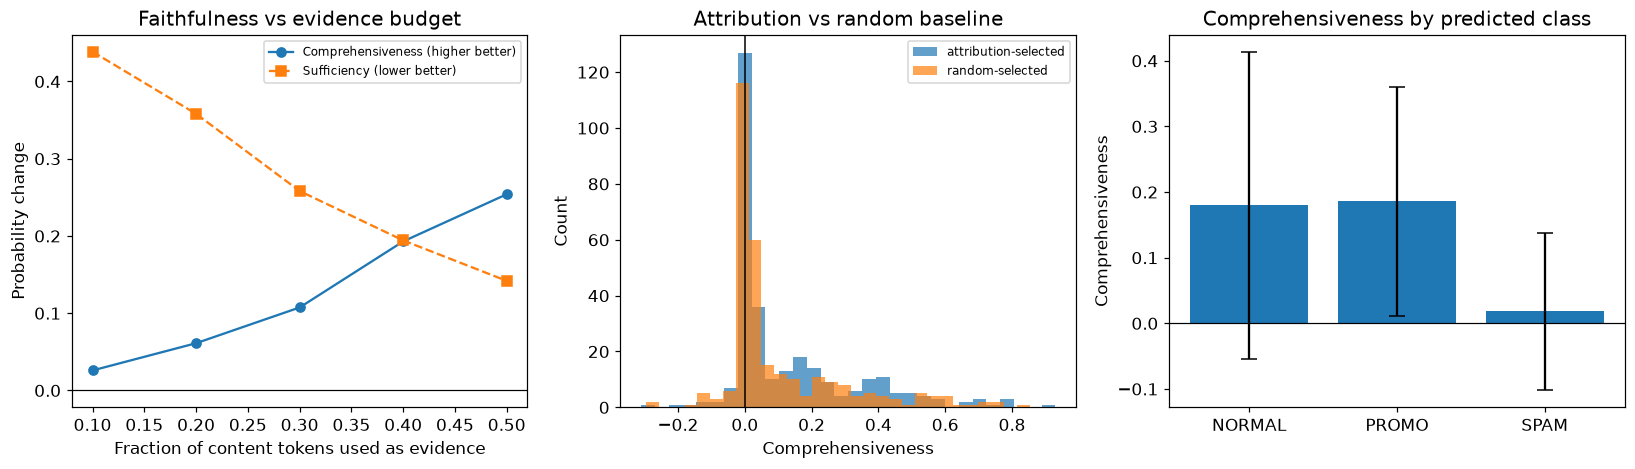

In [32]:
if FAITHFULNESS.get("status") == "DONE" and len(faith_rows) > 0:
    faith_df = pd.DataFrame(faith_rows)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))

    # (1) AOPC curves: comprehensiveness vs random, by evidence budget
    comp_curve = np.array([r["per_fraction_comp"] for r in faith_rows]).mean(0)
    suff_curve = np.array([r["per_fraction_suff"] for r in faith_rows]).mean(0)
    axes[0].plot(FRACTIONS, comp_curve, "o-", label="Comprehensiveness (higher better)")
    axes[0].plot(FRACTIONS, suff_curve, "s--", label="Sufficiency (lower better)")
    axes[0].axhline(0, color="k", lw=0.8)
    axes[0].set_xlabel("Fraction of content tokens used as evidence")
    axes[0].set_ylabel("Probability change")
    axes[0].set_title("Faithfulness vs evidence budget"); axes[0].legend(fontsize=8)

    # (2) attribution vs random
    axes[1].hist(faith_df["comprehensiveness"], bins=30, alpha=0.7, label="attribution-selected")
    axes[1].hist(faith_df["comprehensiveness_random"], bins=30, alpha=0.7, label="random-selected")
    axes[1].axvline(0, color="k", lw=1)
    axes[1].set_xlabel("Comprehensiveness"); axes[1].set_ylabel("Count")
    axes[1].set_title("Attribution vs random baseline"); axes[1].legend(fontsize=8)

    # (3) per predicted class
    labs = [l for l in LABEL_NAMES if (faith_df["pred_label"] == l).any()]
    means = [faith_df.loc[faith_df["pred_label"] == l, "comprehensiveness"].mean() for l in labs]
    sds   = [faith_df.loc[faith_df["pred_label"] == l, "comprehensiveness"].std(ddof=1) for l in labs]
    axes[2].bar(labs, means, yerr=sds, capsize=5)
    axes[2].axhline(0, color="k", lw=0.8)
    axes[2].set_ylabel("Comprehensiveness")
    axes[2].set_title("Comprehensiveness by predicted class")

    plt.tight_layout()
    plt.savefig(DIRS["figures"] / "xai_faithfulness.png", dpi=FIG_DPI, bbox_inches="tight")
    plt.show()

# PARTS 4-6 — The explanation dataset

### 23. Evidence-grounded Bangla realiser

Every sentence is assembled from **verified XAI evidence only**. The realiser can talk
about a URL only if a `suspicious_url`/`url` span was attributed; it can mention an amount
only if a `money_amount` span was attributed. There is no path in the code that can
invent an organisation, a threat, a reward or a number, which is what makes the
hallucination rate in Part 7 structurally near zero rather than merely low.

Class-awareness is built in, addressing PART 18 directly: for PROMO and NORMAL the same
surface features (price, USSD code, dial instruction) are described as ordinary content,
and the safety advice becomes *verify through the official app* rather than *this is
fraud*. A promotional SMS is never called malicious just because it contains a USSD code.

Surface variation is driven by a hash of the message, so the output is deterministic and
reproducible, yet not the same sentence for every record.

In [33]:
# ---------------------------------------------------------------------------
# Bangla realisation resources. Every phrase is a template slot filled ONLY with
# verified evidence spans.
# ---------------------------------------------------------------------------
CLASS_STATEMENT = {
    "SPAM": [
        "এই বার্তাটি প্রতারণামূলক (স্মিশিং) বলে শনাক্ত করা হয়েছে।",
        "বার্তাটিকে ঝুঁকিপূর্ণ বা প্রতারণামূলক হিসেবে চিহ্নিত করা হয়েছে।",
        "এই এসএমএসটি স্মিশিং বা প্রতারণার চেষ্টা বলে মনে হচ্ছে।",
    ],
    "PROMO": [
        "এটি একটি প্রচারমূলক (প্রমোশনাল) বার্তা।",
        "বার্তাটি একটি অফার বা প্যাকেজ সংক্রান্ত প্রচারমূলক এসএমএস।",
        "এটি সাধারণ বিজ্ঞাপন বা অফারের বার্তা হিসেবে শনাক্ত হয়েছে।",
    ],
    "NORMAL": [
        "এটি একটি সাধারণ বার্তা।",
        "বার্তাটিকে স্বাভাবিক ও নিরাপদ বার্তা হিসেবে শনাক্ত করা হয়েছে।",
        "এই এসএমএসটিতে প্রতারণার লক্ষণ পাওয়া যায়নি।",
    ],
}

# Why each evidence type matters — worded differently for SPAM vs PROMO/NORMAL.
EV_WHY = {
    "suspicious_url": {
        "SPAM":   "অচেনা বা সংক্ষিপ্ত লিংক দিয়ে ভুয়া ওয়েবসাইটে নিয়ে গিয়ে তথ্য চুরি করা হয়",
        "OTHER":  "লিংকটি বার্তার সঙ্গে যুক্ত, তবে এটি একাই ঝুঁকির প্রমাণ নয়"},
    "url": {
        "SPAM":   "লিংকে ক্লিক করালে ভুয়া পেজে নেওয়ার ঝুঁকি থাকে",
        "OTHER":  "প্রতিষ্ঠানের ওয়েব ঠিকানা দেওয়া হয়েছে"},
    "urgency": {
        "SPAM":   "তাড়াহুড়া তৈরি করে ভাবার সময় না দেওয়াই প্রতারকদের সাধারণ কৌশল",
        "OTHER":  "অফারের সময়সীমা বোঝাতে এমন শব্দ ব্যবহার করা হয়"},
    "sensitive_info_request": {
        "SPAM":   "পিন, ওটিপি বা পাসওয়ার্ড কোনো প্রতিষ্ঠান কখনোই এসএমএসে চায় না",
        "OTHER":  "যাচাই সংক্রান্ত শব্দ ব্যবহার করা হয়েছে"},
    "financial_request": {
        "SPAM":   "টাকা পাঠাতে বা লেনদেন করতে বলা প্রতারণার বড় লক্ষণ",
        "OTHER":  "রিচার্জ বা পেমেন্ট সংক্রান্ত স্বাভাবিক তথ্য"},
    "impersonation": {
        "SPAM":   "পরিচিত প্রতিষ্ঠানের নাম ব্যবহার করে বিশ্বাস অর্জনের চেষ্টা করা হয়",
        "OTHER":  "প্রতিষ্ঠানের নাম উল্লেখ করা হয়েছে"},
    "reward_claim": {
        "SPAM":   "না চাইতেই পুরস্কার বা টাকা জেতার দাবি প্রায় সবসময়ই ভুয়া",
        "OTHER":  "উপহার বা ছাড়ের প্রস্তাব দেওয়া হয়েছে"},
    "threat_warning": {
        "SPAM":   "অ্যাকাউন্ট বন্ধ বা জরিমানার ভয় দেখিয়ে দ্রুত সাড়া দিতে বাধ্য করা হয়",
        "OTHER":  "মেয়াদ বা শর্ত সংক্রান্ত তথ্য দেওয়া হয়েছে"},
    "suspicious_action": {
        "SPAM":   "ক্লিক করা বা ফরম পূরণের নির্দেশ দিয়ে তথ্য হাতিয়ে নেওয়া হয়",
        "OTHER":  "কী করতে হবে তা বলা হয়েছে"},
    "phone_number": {
        "SPAM":   "অচেনা নম্বরে যোগাযোগ করতে বলা ঝুঁকিপূর্ণ",
        "OTHER":  "যোগাযোগের নম্বর দেওয়া হয়েছে"},
    "ussd_code": {
        "SPAM":   "ডায়াল কোডটি এখানে সন্দেহজনক প্রেক্ষাপটে ব্যবহৃত হয়েছে",
        "OTHER":  "অফারটি নেওয়ার স্বাভাবিক ডায়াল কোড"},
    "money_amount": {
        "SPAM":   "টাকার অঙ্ক দেখিয়ে দ্রুত সাড়া দিতে প্ররোচিত করা হয়েছে",
        "OTHER":  "প্যাকেজের দাম জানানো হয়েছে"},
    "promo_offer": {
        "SPAM":   "অফারের ভাষা ব্যবহার করে বার্তাটিকে বৈধ দেখানোর চেষ্টা করা হয়েছে",
        "OTHER":  "প্যাকেজ বা অফারের স্বাভাবিক তথ্য"},
    "linguistic_indicator": {
        "SPAM":   "এই শব্দগুলোর ব্যবহার প্রতারণামূলক বার্তায় বেশি দেখা যায়",
        "OTHER":  "এই শব্দগুলো বার্তাটির ধরন বোঝাতে সাহায্য করেছে"},
}

SAFETY = {
    "SPAM": [
        "কোনো লিংকে ক্লিক করবেন না এবং পিন, ওটিপি বা পাসওয়ার্ড কাউকে দেবেন না।",
        "বার্তাটির নির্দেশ অনুসরণ করবেন না; প্রয়োজনে সরাসরি প্রতিষ্ঠানের অফিসিয়াল নম্বরে যোগাযোগ করুন।",
        "সাড়া দেবেন না, লিংকে ঢুকবেন না এবং কোনো ব্যক্তিগত তথ্য শেয়ার করবেন না।",
    ],
    "PROMO": [
        "অফারটি নিতে চাইলে অপারেটরের অফিসিয়াল অ্যাপ বা কাস্টমার কেয়ারে যাচাই করে নিন।",
        "আগ্রহ না থাকলে বার্তাটি উপেক্ষা করতে পারেন; তবে ব্যক্তিগত তথ্য দেওয়ার দরকার নেই।",
        "অফারের শর্ত অফিসিয়াল উৎস থেকে দেখে নেওয়াই ভালো।",
    ],
    "NORMAL": [
        "এখানে বিশেষ ঝুঁকির লক্ষণ পাওয়া যায়নি, তবে সবসময় সতর্ক থাকা ভালো।",
        "বার্তাটি স্বাভাবিক মনে হচ্ছে; কোনো পদক্ষেপ নেওয়ার প্রয়োজন নেই।",
        "এটি সাধারণ তথ্যমূলক বার্তা বলে মনে হচ্ছে।",
    ],
}

PROMO_CONTRAST = ("বৈধ প্রচারমূলক বার্তাতেও দাম, প্যাকেজ বা ডায়াল কোড থাকে — "
                  "শুধু এগুলো থাকলেই বার্তাটি প্রতারণামূলক হয় না।")
SPAM_CONTRAST  = ("বৈধ অফারের বার্তায় সাধারণত গোপন তথ্য চাওয়া হয় না বা "
                  "অচেনা লিংকে ক্লিক করতে বলা হয় না — এখানেই পার্থক্য।")

def _pick(seq, key):
    """Deterministic variation: same SMS always gets the same phrasing."""
    h = int(hashlib.md5(key.encode("utf-8")).hexdigest()[:8], 16)
    return seq[h % len(seq)]

def _why(etype, label):
    d = EV_WHY.get(etype, EV_WHY["linguistic_indicator"])
    return d["SPAM"] if label == "SPAM" else d["OTHER"]

def _q(s):
    return "\u201c" + s.strip() + "\u201d"

_SENT_SPLIT = re.compile(r"(?:।|!|\?|(?<!\d)\.(?!\d))+")

def _sent_count(t):
    """Sentence count for Bangla. A period between digits (96.0%) is NOT a boundary —
    counting it as one was rejecting every HIGH-proficiency explanation."""
    return len([x for x in _SENT_SPLIT.split(str(t)) if x.strip()])
print("Bangla realisation resources loaded.")

Bangla realisation resources loaded.


In [34]:
def render_explanation(rec, level):
    """rec = output of explain_sms(). level in {static, low, medium, high}.

    Only rec['evidence'] and rec['predicted_label'] / rec['confidence'] are used.
    No external fact can enter the text.
    """
    label = rec["predicted_label"]
    conf  = float(rec["confidence"])
    ev    = rec["evidence"]
    sms   = rec["sms"]
    key   = sms

    stmt = _pick(CLASS_STATEMENT[label], key)
    safe = _pick(SAFETY[label], key + level)

    if not ev:
        base = {"low":    f"{stmt} {safe}",
                "medium": f"{stmt} বার্তাটির কোনো নির্দিষ্ট অংশ আলাদাভাবে শক্ত প্রমাণ হিসেবে "
                          f"পাওয়া যায়নি; সিদ্ধান্তটি বার্তাটির সামগ্রিক ভাষার ধরন থেকে এসেছে। {safe}",
                "high":   f"{stmt} মডেলের আস্থা {conf*100:.1f}%। টোকেন-পর্যায়ের বিশ্লেষণে "
                          f"কোনো একক অংশ নির্ণায়ক প্রমাণ হিসেবে উঠে আসেনি, তাই সিদ্ধান্তটি "
                          f"বার্তার সামগ্রিক গঠনের উপর নির্ভরশীল এবং এর ব্যাখ্যাগত নিশ্চয়তা সীমিত। {safe}",
                "static": f"{stmt} বার্তাটির নির্দিষ্ট কোনো অংশ প্রধান প্রমাণ হিসেবে চিহ্নিত হয়নি; "
                          f"সিদ্ধান্তটি সামগ্রিক ভাষাশৈলীর ভিত্তিতে নেওয়া হয়েছে। {safe}"}
        return base[level]

    top = ev[:3]

    # ---------------- LOW: 1-3 short sentences, one or two strongest cues -------------
    if level == "low":
        e1 = top[0]
        parts = [stmt, f"বার্তাটিতে {_q(e1['text'])} অংশটি সবচেয়ে বেশি গুরুত্ব পেয়েছে "
                       f"({e1['type_bn']})।"]
        if len(top) > 1:
            parts[-1] = (f"বার্তাটিতে {_q(top[0]['text'])} এবং {_q(top[1]['text'])} "
                         f"অংশ দুটি সবচেয়ে বেশি গুরুত্ব পেয়েছে।")
        parts.append(safe)
        return " ".join(parts)

    # ---------------- MEDIUM: 2-5 sentences, 2-3 cues + why + contrast ---------------
    if level == "medium":
        cues = "; ".join(f"{_q(e['text'])} ({e['type_bn']})" for e in top)
        why  = _why(top[0]["type"], label)
        out = [stmt, f"বার্তায় যে অংশগুলো সিদ্ধান্তে সবচেয়ে বেশি প্রভাব ফেলেছে: {cues}।",
               f"এটি গুরুত্বপূর্ণ কারণ {why}।"]
        types = {e["type"] for e in ev}
        if label == "SPAM" and types & {"ussd_code", "money_amount", "promo_offer"}:
            out.append(SPAM_CONTRAST)
        elif label == "PROMO" and types & {"ussd_code", "money_amount", "url", "phone_number"}:
            out.append(PROMO_CONTRAST)
        out.append(safe)
        return " ".join(out[:5])

    # ---------------- HIGH: 3-7 sentences, contributions + uncertainty ---------------
    if level == "high":
        contrib = "; ".join(
            f"{_q(e['text'])} — {e['type_bn']}, আপেক্ষিক অবদান {e['importance']*100:.1f}%"
            for e in ev[:4])
        why_lines = "; ".join(f"{_q(e['text'])}: {_why(e['type'], label)}" for e in top[:2])
        out = [
            f"{stmt} মডেলের ক্যালিব্রেটেড আস্থা {conf*100:.1f}%।",
            f"ইন্টিগ্রেটেড গ্রেডিয়েন্ট পদ্ধতিতে টোকেন-পর্যায়ের বিশ্লেষণে যে অংশগুলো "
            f"পূর্বাভাসের পক্ষে সবচেয়ে বেশি অবদান রেখেছে: {contrib}।",
            f"ব্যাখ্যা: {why_lines}।",
        ]
        types = {e["type"] for e in ev}
        if label == "SPAM" and types & {"ussd_code", "money_amount", "promo_offer"}:
            out.append("উল্লেখ্য, ডায়াল কোড বা টাকার অঙ্ক নিজে থেকে প্রতারণার প্রমাণ নয়; "
                       "এখানে অন্য সন্দেহজনক উপাদানের সঙ্গে মিলিত হয়ে এগুলো ঝুঁকি বাড়িয়েছে।")
        elif label == "PROMO":
            out.append("এই উপাদানগুলো বৈধ প্রচারমূলক বার্তার স্বাভাবিক বৈশিষ্ট্য, "
                       "তাই এগুলোর উপস্থিতি প্রতারণার ইঙ্গিত হিসেবে গণ্য করা হয়নি।")
        if conf < 0.70:
            out.append(f"তবে আস্থার মান তুলনামূলকভাবে কম ({conf*100:.1f}%), তাই এই "
                       f"সিদ্ধান্তটি অনিশ্চিত এবং মানুষের যাচাই কাম্য।")
        elif conf < 0.90:
            out.append(f"আস্থার মান মাঝারি ({conf*100:.1f}%), তাই সিদ্ধান্তটি "
                       f"যুক্তিসঙ্গত হলেও সম্পূর্ণ নিশ্চিত নয়।")
        out.append(safe)
        return " ".join(out[:7])

    # ---------------- STATIC: one fixed, moderately detailed style -------------------
    cues = ", ".join(_q(e["text"]) for e in top)
    why  = _why(top[0]["type"], label)
    return (f"{stmt} মডেলের আস্থা {conf*100:.1f}%। "
            f"সিদ্ধান্তে সবচেয়ে বেশি প্রভাব ফেলেছে বার্তার এই অংশগুলো: {cues}। "
            f"এগুলো গুরুত্বপূর্ণ কারণ {why}। {safe}")

# quick self-check on one message per class
if RUN_XAI:
    for cid in [SPAM_ID, PROMO_ID, NORMAL_ID]:
        i = [j for j in df.index[test_mask] if df.loc[j, COL_LABEL_ID] == cid][0]
        r = explain_sms(str(df.loc[i, BEST_TEXT_COL]))
        print("=" * 74)
        print("SMS   :", r["sms"][:80])
        print("PRED  :", r["predicted_label"], f"({r['confidence']:.3f})")
        for lv in ["static", "low", "medium", "high"]:
            t = render_explanation(r, lv)
            print(f"\n[{lv.upper()}] ({_sent_count(t)} sentences)\n{t}")
        print()

SMS   : [Pathao] আমরা Techland BD থেকে আপনার পণ্য XXXXXFKER টি সংগ্রহ করেছি। ট্র্যাক করু
PRED  : NORMAL (0.955)

[STATIC] (6 sentences)
এই এসএমএসটিতে প্রতারণার লক্ষণ পাওয়া যায়নি। মডেলের আস্থা 95.5%। সিদ্ধান্তে সবচেয়ে বেশি প্রভাব ফেলেছে বার্তার এই অংশগুলো: “https://ptho.app/XXXXX”, “[Pathao]”, “Techland”। এগুলো গুরুত্বপূর্ণ কারণ প্রতিষ্ঠানের ওয়েব ঠিকানা দেওয়া হয়েছে। এটি সাধারণ তথ্যমূলক বার্তা বলে মনে হচ্ছে।

[LOW] (4 sentences)
এই এসএমএসটিতে প্রতারণার লক্ষণ পাওয়া যায়নি। বার্তাটিতে “https://ptho.app/XXXXX” এবং “[Pathao]” অংশ দুটি সবচেয়ে বেশি গুরুত্ব পেয়েছে। বার্তাটি স্বাভাবিক মনে হচ্ছে; কোনো পদক্ষেপ নেওয়ার প্রয়োজন নেই।

[MEDIUM] (5 sentences)
এই এসএমএসটিতে প্রতারণার লক্ষণ পাওয়া যায়নি। বার্তায় যে অংশগুলো সিদ্ধান্তে সবচেয়ে বেশি প্রভাব ফেলেছে: “https://ptho.app/XXXXX” (ওয়েব লিংক); “[Pathao]” (ভাষাগত ইঙ্গিত); “Techland” (ভাষাগত ইঙ্গিত)। এটি গুরুত্বপূর্ণ কারণ প্রতিষ্ঠানের ওয়েব ঠিকানা দেওয়া হয়েছে। এটি সাধারণ তথ্যমূলক বার্তা বলে মনে হচ্ছে।

[HIGH] (7 sentences)
এই এসএমএসটিতে

### refinement with `rnnandi/bangla-smollm-135m`

`rnnandi/bangla-smollm-135m` is a **base** (non-instruction-tuned) 135M model. It is
loaded and used exactly as the specification asks, with near-deterministic decoding, but
its output is treated as a *candidate* rather than as the answer: a refinement is kept
only if it passes every hallucination, evidence-consistency and length check in Part 7.
Otherwise the grounded text stands. The acceptance rate is recorded in the audit log and
should be reported honestly in the dissertation — for a base model of this size it will
be low, and that is a finding, not a failure of the pipeline.

In [35]:
SMOLLM_STATE = {"loaded": False, "reason": "disabled"}
smollm_tok = smollm_model = None

if USE_SMOLLM:
    try:
        from transformers import AutoModelForCausalLM
        smollm_tok = AutoTokenizer.from_pretrained(SMOLLM_ID)
        smollm_model = AutoModelForCausalLM.from_pretrained(
            SMOLLM_ID, torch_dtype=torch.bfloat16 if BF16_OK else torch.float32)
        smollm_model = smollm_model.to(DEVICE).eval()
        if smollm_tok.pad_token is None:
            smollm_tok.pad_token = smollm_tok.eos_token
        SMOLLM_STATE = {"loaded": True, "model": SMOLLM_ID,
                        "params": int(sum(p.numel() for p in smollm_model.parameters()))}
        print(f"Loaded {SMOLLM_ID} ({SMOLLM_STATE['params']/1e6:.1f}M params) on {DEVICE}")
    except Exception as e:
        SMOLLM_STATE = {"loaded": False, "reason": str(e)[:300]}
        print(f"Could not load {SMOLLM_ID}: {e}")
        print("-> Falling back to the grounded realiser for every record.")

LEVEL_BN = {"static": "সাধারণ", "low": "সহজ", "medium": "মাঝারি", "high": "বিস্তারিত"}

def build_generation_prompt(rec, level):
    ev_lines = "\n".join(
        f"- {e['text']} ({e['type_bn']}, গুরুত্ব {e['importance']:.2f})"
        for e in rec["evidence"][:4]) or "- (নির্দিষ্ট প্রমাণ পাওয়া যায়নি)"
    return (
        f"এসএমএস:\n{rec['sms']}\n\n"
        f"পূর্বাভাসিত শ্রেণি: {rec['predicted_label']}\n"
        f"মডেলের আস্থা: {rec['confidence']:.2f}\n"
        f"যাচাইকৃত XAI প্রমাণ:\n{ev_lines}\n"
        f"ব্যাখ্যার ধরন: {LEVEL_BN[level]}\n\n"
        f"নির্দেশনা: শুধুমাত্র উপরের এসএমএস, শ্রেণি, আস্থা ও যাচাইকৃত প্রমাণের ভিত্তিতে "
        f"বাংলায় ব্যাখ্যা লিখুন। নতুন কোনো লিংক, নম্বর, টাকার অঙ্ক, প্রতিষ্ঠান বা "
        f"হুমকি উদ্ভাবন করবেন না।\n\nব্যাখ্যা:")

@torch.no_grad()
def smollm_generate(prompt, max_new_tokens=90):
    if not SMOLLM_STATE.get("loaded"):
        return None
    enc = smollm_tok(prompt, return_tensors="pt", truncation=True,
                     max_length=768).to(DEVICE)
    out = smollm_model.generate(
        **enc, max_new_tokens=max_new_tokens,
        do_sample=False,               # deterministic — this is a research dataset
        num_beams=1, repetition_penalty=1.15,
        pad_token_id=smollm_tok.pad_token_id,
        eos_token_id=smollm_tok.eos_token_id)
    text = smollm_tok.decode(out[0][enc["input_ids"].shape[1]:], skip_special_tokens=True)
    return text.strip().split("এসএমএস:")[0].strip()

if SMOLLM_STATE.get("loaded") and RUN_XAI:
    try:
        _i = [j for j in df.index[test_mask] if df.loc[j, COL_LABEL_ID] == SPAM_ID][0]
        _r = explain_sms(str(df.loc[_i, BEST_TEXT_COL]))
        _out = smollm_generate(build_generation_prompt(_r, "low")) or ""
        print("\nSample raw generation from the base model (before validation):")
        print(repr(_out[:300]))
        print("\nThis is unfiltered base-model output. Whether it survives the Part 7 "
              "checks is exactly what the acceptance rate in the audit log measures.")
    except Exception as _e:
        print("Demo generation failed (pipeline still runs on the grounded realiser):", _e)
free_gpu()

config.json:   0%|          | 0.00/774 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.75M [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 31.2MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/829 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/164 [00:00<?, ?B/s]

Loaded rnnandi/bangla-smollm-135m (210.0M params) on cuda


[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.



Sample raw generation from the base model (before validation):
'এই ধরনের ব্যাখ্যাটি ব্যবহার করে আপনি আমাদের ওয়েবসাইট এবং অন্যান্য অনলাইন প্ল্যাটফর্মগুলিতে একটিভ থাকুক তা নিশ্চিত করতে পারেন । আর যদি অন্য কেউ আপনাকে অনুসরণ করার চেষ্টা করেন তবে অবশ্যই তাকে অবহিত করা হবে যাতে তিনি এটাকে আরও উন্নত উপায়ে কাজে লাগাতে পারে , অন্যথায় এটা তার জন্য অনেক কঠিন হয়ে দাঁড়া'

This is unfiltered base-model output. Whether it survives the Part 7 checks is exactly what the acceptance rate in the audit log measures.


# PART 7 — Automatic dataset validation

Six independent checks run on every explanation. A record is written only if all four of
its variants pass; otherwise it is regenerated (up to `MAX_REGEN_ATTEMPTS`) and finally
discarded, with the reason recorded in the audit log.

| Check | What it catches |
|---|---|
| `evidence_consistency` | every quoted span must be a literal substring of the SMS |
| `hallucination` | invented URLs, phone numbers, amounts, organisations, threats, rewards |
| `label_consistency` | a PROMO/NORMAL message described as fraudulent |
| `length` | empty, too short, or over-long for the requested proficiency level |
| `repetition` | degenerate repeated n-grams (the classic small-LM failure) |
| `duplicate` | identical or near-identical explanations across records |

In [36]:
BN_DIGITS = str.maketrans("০১২৩৪৫৬৭৮৯", "0123456789")

def _norm_digits(s):
    return str(s).translate(BN_DIGITS)

QUOTE_RE  = re.compile(r"[\u201c\u201d\"']([^\u201c\u201d\"']{1,80})[\u201c\u201d\"']")
NUMTOK_RE = re.compile(r"\d[\d,\.]*")
ORG_HINTS = ["বিকাশ", "নগদ", "রকেট", "ব্র্যাক", "ডাচ", "সোনালী", "ইসলামী", "সিটি ব্যাংক",
             "গ্রামীণফোন", "রবি", "এয়ারটেল", "বাংলালিংক", "টেলিটক",
             "bkash", "nagad", "rocket", "brac", "dbbl", "grameenphone", "robi",
             "airtel", "banglalink", "teletalk", "paypal", "amazon", "daraz"]
FRAUD_TERMS = ["প্রতারণামূলক", "প্রতারণা", "স্মিশিং", "ভুয়া", "জালিয়াতি", "প্রতারক", "ফিশিং"]
NEGATIONS   = ["নয়", "হয় না", "পাওয়া যায়নি", "গণ্য করা হয়নি", "না।", "নেই"]

LENGTH_RULES = {"low": (1, 3), "medium": (2, 5), "high": (3, 7), "static": (2, 6)}
MIN_CHARS    = {"low": 25, "medium": 60, "high": 110, "static": 60}
MAX_CHARS    = {"low": 320, "medium": 620, "high": 1200, "static": 700}

def check_evidence_consistency(rec, text):
    """Every quoted span must literally occur in the SMS."""
    sms = rec["sms"]
    bad = [q for q in QUOTE_RE.findall(text) if q.strip() and q.strip() not in sms]
    return (len(bad) == 0), bad

_TRIM = "\u201c\u201d\"'()[]{}<>।,;:!?\u0964 "

def _canon_num(x):
    x = str(x).replace(",", "")
    return x.rstrip("0").rstrip(".") if "." in x else x

def check_hallucination(rec, text):
    """No URL, number, amount or organisation may appear that is not in the SMS,
    apart from the model's own confidence / importance percentages."""
    sms = rec["sms"]
    sms_n, txt_n = _norm_digits(sms), _norm_digits(text)
    issues = []

    for u in URL_RE.findall(text):
        u = u.strip().strip(_TRIM)
        if u and u not in sms:
            issues.append(f"invented_url:{u[:40]}")

    allowed = set(NUMTOK_RE.findall(sms_n))
    allowed.add(f"{rec['confidence']*100:.1f}")
    allowed.add(f"{rec['confidence']*100:.0f}")
    for e in rec["evidence"]:
        allowed.add(f"{e['importance']*100:.1f}")
        allowed.update(NUMTOK_RE.findall(_norm_digits(e["text"])))
    allowed_canon = {_canon_num(a) for a in allowed}
    for n in NUMTOK_RE.findall(txt_n):
        if _canon_num(n) not in allowed_canon:
            issues.append(f"invented_number:{n}")

    low_sms, low_txt = sms.lower(), text.lower()
    for org in ORG_HINTS:
        if org in low_txt and org not in low_sms:
            issues.append(f"invented_org:{org}")

    for ph in PHONE_RE.findall(text):
        if ph.strip(_TRIM) not in sms:
            issues.append(f"invented_phone:{ph}")
    return (len(issues) == 0), issues

def check_label_consistency(rec, text):
    """A PROMO or NORMAL message must not be asserted to be fraudulent.
    Negated mentions ('... is not fraud') are allowed, which is why the check looks at
    what follows the term rather than at the term alone."""
    if rec["predicted_label"] == "SPAM":
        return True, []
    issues = []
    for t in FRAUD_TERMS:
        for m in re.finditer(re.escape(t), text):
            tail = text[m.end():m.end() + 30]
            if not any(neg in tail for neg in NEGATIONS):
                issues.append(f"asserts_fraud_for_{rec['predicted_label']}:{t}")
    return (len(issues) == 0), issues

def check_length(text, level):
    lo, hi = LENGTH_RULES[level]
    n = _sent_count(text)
    issues = []
    if not text.strip():
        issues.append("empty")
    if len(text) < MIN_CHARS[level]:
        issues.append(f"too_short_chars:{len(text)}")
    if len(text) > MAX_CHARS[level]:
        issues.append(f"too_long_chars:{len(text)}")
    if n < lo:
        issues.append(f"too_few_sentences:{n}<{lo}")
    if n > hi:
        issues.append(f"too_many_sentences:{n}>{hi}")
    return (len(issues) == 0), issues

def check_repetition(text, n=4, max_ratio=0.30):
    words = text.split()
    if len(words) < n * 2:
        return True, []
    grams = [" ".join(words[i:i + n]) for i in range(len(words) - n + 1)]
    c = Counter(grams)
    rep = 1 - len(c) / len(grams)
    return (rep <= max_ratio), ([f"repetition_ratio:{rep:.2f}"] if rep > max_ratio else [])

def validate_explanation(rec, text, level):
    """Returns (ok, failure_codes)."""
    fails = []
    ok, b = check_evidence_consistency(rec, text)
    if not ok: fails += [f"evidence:{x}" for x in b]
    ok, b = check_hallucination(rec, text)
    if not ok: fails += [f"hallucination:{x}" for x in b]
    ok, b = check_label_consistency(rec, text)
    if not ok: fails += [f"label:{x}" for x in b]
    ok, b = check_length(text, level)
    if not ok: fails += [f"length:{x}" for x in b]
    ok, b = check_repetition(text)
    if not ok: fails += [f"repetition:{x}" for x in b]
    return (len(fails) == 0), fails

print("Validators ready:", list(LENGTH_RULES))

Validators ready: ['low', 'medium', 'high', 'static']


### 25. PART 6 — building 3,000+ validated records

SMS and label come straight from the existing dataset; nothing is invented and no label
is changed. Sampling is stratified across NORMAL / PROMO / SPAM and across the original
splits, and the `source_split` column is preserved so the dissertation can report exactly
which messages the classifier had seen during its own training.

Each record carries the classifier's prediction *and* the dataset's gold label. Where they
disagree, the row is kept and flagged (`pred_matches_gold = False`) — the explanation
explains what the model actually decided, which is the honest thing for an XAI dataset,
while `label` stays the gold label as required.

In [37]:
EXPL_RECORDS, AUDIT_LOG = [], []
LEVELS = ["static", "low", "medium", "high"]

def _make_variants(rec):
    """Grounded text first; optional SmolLM refinement kept only if it validates."""
    out, prov = {}, {}
    for lv in LEVELS:
        grounded = render_explanation(rec, lv)
        ok, fails = validate_explanation(rec, grounded, lv)
        chosen, src = (grounded, "grounded") if ok else (None, None)

        if SMOLLM_STATE.get("loaded"):
            try:
                cand = smollm_generate(build_generation_prompt(rec, lv))
                if cand:
                    ok_c, _ = validate_explanation(rec, cand, lv)
                    if ok_c:
                        chosen, src = cand, "smollm"
            except Exception:
                pass

        if chosen is None:                       # grounded failed: repair by truncation
            sents = [s for s in re.split(r"(?<=।)\s*", grounded) if s.strip()]
            hi = LENGTH_RULES[lv][1]
            repaired = " ".join(sents[:hi])
            ok_r, fails_r = validate_explanation(rec, repaired, lv)
            if ok_r:
                chosen, src = repaired, "grounded_repaired"
            else:
                return None, {"level": lv, "fails": fails + fails_r}
        out[lv], prov[lv] = chosen, src
    return out, prov

if RUN_BUILD_EXPL_DS:
    set_seed(SEED)
    rng = np.random.RandomState(SEED)

    # stratified sample of UNIQUE messages, balanced across classes
    per_class = int(np.ceil(TARGET_EXPL_RECORDS / NUM_CLASSES))
    chosen_idx = []
    for c in range(NUM_CLASSES):
        cand = df.index[(df[COL_LABEL_ID] == c)].tolist()
        seen, uniq = set(), []
        for i in cand:
            t = normalize_bn(str(df.loc[i, BEST_TEXT_COL]))
            if len(t.split()) < 3 or t in seen:
                continue
            seen.add(t); uniq.append(i)
        take = min(len(uniq), per_class)
        chosen_idx += list(rng.choice(uniq, take, replace=False))
        print(f"  {LABEL_NAMES[c]:7s}: {len(uniq)} unique available -> sampling {take}")
    rng.shuffle(chosen_idx)

    print(f"\nGenerating explanations for {len(chosen_idx)} unique messages "
          f"x {len(LEVELS)} variants ...")
    t0 = time.time()
    seen_texts = set()

    for n, i in enumerate(chosen_idx):
        sms_raw = str(df.loc[i, BEST_TEXT_COL])
        gold    = str(df.loc[i, COL_LABEL])
        try:
            rec = explain_sms(sms_raw, topk=6)
        except Exception as e:
            AUDIT_LOG.append({"index": int(i), "status": "rejected",
                              "reason": f"xai_error:{str(e)[:120]}"})
            continue

        if rec["sms"] in seen_texts:
            AUDIT_LOG.append({"index": int(i), "status": "rejected",
                              "reason": "duplicate_sms"})
            continue

        variants, prov, attempts = None, None, 0
        while variants is None and attempts < MAX_REGEN_ATTEMPTS:
            attempts += 1
            variants, prov = _make_variants(rec)
            if variants is None:
                info = prov
                rec = explain_sms(sms_raw, topk=max(2, 6 - attempts))   # retry, fewer cues
        if variants is None:
            AUDIT_LOG.append({"index": int(i), "status": "rejected",
                              "reason": f"validation_failed_after_{attempts}_attempts",
                              "detail": str(info)[:200]})
            continue

        seen_texts.add(rec["sms"])
        EXPL_RECORDS.append({
            "SMS": rec["sms"],
            "label": gold,
            "label_id": int(df.loc[i, COL_LABEL_ID]),
            "predicted_label": rec["predicted_label"],
            "confidence": rec["confidence"],
            "pred_matches_gold": bool(rec["predicted_label"] == gold),
            "xai_evidence": json.dumps(
                [{k: e[k] for k in ["text", "type", "type_bn", "importance",
                                    "char_start", "char_end"]} for e in rec["evidence"]],
                ensure_ascii=False),
            "n_evidence": len(rec["evidence"]),
            "static_explanation":          variants["static"],
            "adaptive_explanation_low":    variants["low"],
            "adaptive_explanation_medium": variants["medium"],
            "adaptive_explanation_high":   variants["high"],
            "source_split": str(df.loc[i, "_split_norm"]),
            "source_index": int(i),
            "generator_static": prov["static"], "generator_low": prov["low"],
            "generator_medium": prov["medium"], "generator_high": prov["high"],
        })
        AUDIT_LOG.append({"index": int(i), "status": "accepted", "attempts": attempts})

        if (n + 1) % 200 == 0:
            el = time.time() - t0
            print(f"  {n+1}/{len(chosen_idx)} processed | kept {len(EXPL_RECORDS)} "
                  f"| {el:.0f}s | eta {el/(n+1)*(len(chosen_idx)-n-1):.0f}s")

    expl_df = pd.DataFrame(EXPL_RECORDS)
    print(f"\nGenerated {len(expl_df)} valid records in {time.time()-t0:.0f}s")
    print("Class distribution:\n", expl_df["label"].value_counts())
    print("\nGenerator provenance (static variant):\n",
          expl_df["generator_static"].value_counts())
    if len(expl_df) < 3000:
        print(f"\nWARNING: only {len(expl_df)} records (< 3000). "
              f"Raise TARGET_EXPL_RECORDS and re-run this cell.")
    expl_df.to_csv(DIRS["explanations"] / "explanation_dataset_raw.csv",
                   index=False, encoding="utf-8-sig")
else:
    expl_df = pd.read_csv(DIRS["explanations"] / "explanation_dataset_raw.csv")
    print("Loaded existing raw explanation dataset:", expl_df.shape)
free_gpu()

  NORMAL : 5570 unique available -> sampling 1067
  PROMO  : 3980 unique available -> sampling 1067
  SPAM   : 6880 unique available -> sampling 1067

Generating explanations for 3201 unique messages x 4 variants ...
  400/3201 processed | kept 251 | 4287s | eta 30020s
  600/3201 processed | kept 369 | 6455s | eta 27982s
  1000/3201 processed | kept 615 | 10804s | eta 23779s
  1200/3201 processed | kept 729 | 13011s | eta 21695s
  1400/3201 processed | kept 854 | 15174s | eta 19520s
  2000/3201 processed | kept 1209 | 21832s | eta 13110s
  2200/3201 processed | kept 1345 | 23996s | eta 10918s
  2400/3201 processed | kept 1462 | 26146s | eta 8726s
  2600/3201 processed | kept 1585 | 28309s | eta 6544s
  2800/3201 processed | kept 1699 | 30530s | eta 4372s
  3200/3201 processed | kept 1925 | 34993s | eta 11s

Generated 1925 valid records in 35022s
Class distribution:
 label
NORMAL    808
SPAM      592
PROMO     525
Name: count, dtype: int64

Generator provenance (static variant):
 genera

### 26. Dataset-level validation report (PART 7 continued)

The per-record checks already gated generation. This pass re-runs them over the finished
table and adds the checks that only make sense across records: duplicate SMS, duplicate
explanations, and near-duplicates (token Jaccard ≥ 0.9 within a class).

In [38]:
VALIDATION_REPORT = {"status": "SKIPPED"}

def _jaccard(a, b):
    A, B = set(a.split()), set(b.split())
    return len(A & B) / max(1, len(A | B))

if RUN_AUTO_VALIDATION and len(expl_df) > 0:
    rows, fail_counter = [], Counter()

    for _, r in expl_df.iterrows():
        rec = {"sms": r["SMS"], "predicted_label": r["predicted_label"],
               "confidence": float(r["confidence"]),
               "evidence": json.loads(r["xai_evidence"])}
        row = {"source_index": r["source_index"], "label": r["label"],
               "predicted_label": r["predicted_label"]}
        all_ok = True
        for lv, col in [("static", "static_explanation"), ("low", "adaptive_explanation_low"),
                        ("medium", "adaptive_explanation_medium"),
                        ("high", "adaptive_explanation_high")]:
            ok, fails = validate_explanation(rec, str(r[col]), lv)
            row[f"{lv}_valid"] = ok
            row[f"{lv}_fails"] = ";".join(fails[:5])
            for f in fails:
                fail_counter[f.split(":")[0]] += 1
            all_ok &= ok
        # evidence spans really occur in the SMS
        row["evidence_in_sms"] = all(e["text"] in r["SMS"] for e in rec["evidence"])
        row["all_valid"] = all_ok and row["evidence_in_sms"]
        rows.append(row)

    vdf = pd.DataFrame(rows)

    dup_sms = int(expl_df.duplicated(subset=["SMS"]).sum())
    dup_expl = {lv: int(expl_df.duplicated(subset=[col]).sum())
                for lv, col in [("static", "static_explanation"),
                                ("low", "adaptive_explanation_low"),
                                ("medium", "adaptive_explanation_medium"),
                                ("high", "adaptive_explanation_high")]}
    dup_pair = int(expl_df.duplicated(subset=["SMS", "static_explanation"]).sum())

    # near-duplicate sampling within class (full pairwise would be O(n^2))
    near = 0; checked = 0
    rng = np.random.RandomState(SEED)
    for lab in expl_df["label"].unique():
        sub = expl_df[expl_df["label"] == lab]["adaptive_explanation_medium"].tolist()
        if len(sub) < 2:
            continue
        idx = rng.choice(len(sub), min(400, len(sub)), replace=False)
        for a in range(len(idx)):
            for b in range(a + 1, min(a + 12, len(idx))):
                checked += 1
                if _jaccard(sub[idx[a]], sub[idx[b]]) >= 0.9:
                    near += 1
    near_rate = near / max(1, checked)

    n = len(expl_df)
    VALIDATION_REPORT = {
        "status": "DONE",
        "total_generated": int(len(AUDIT_LOG)) if AUDIT_LOG else n,
        "total_valid": int(vdf["all_valid"].sum()),
        "total_rejected": int(sum(1 for a in AUDIT_LOG if a["status"] == "rejected")),
        "final_records": n,
        "hallucination_rate": float(fail_counter["hallucination"] / max(1, n * 4)),
        "evidence_inconsistency_rate": float(1 - vdf["evidence_in_sms"].mean()),
        "label_inconsistency_rate": float(fail_counter["label"] / max(1, n * 4)),
        "length_violation_rate": float(fail_counter["length"] / max(1, n * 4)),
        "repetition_rate": float(fail_counter["repetition"] / max(1, n * 4)),
        "duplicate_sms": dup_sms,
        "duplicate_explanations": dup_expl,
        "duplicate_sms_plus_explanation": dup_pair,
        "near_duplicate_rate_sampled": float(near_rate),
        "per_level_valid_rate": {lv: float(vdf[f"{lv}_valid"].mean())
                                 for lv in ["static", "low", "medium", "high"]},
        "class_distribution": {k: int(v) for k, v in expl_df["label"].value_counts().items()},
        "pred_matches_gold_rate": float(expl_df["pred_matches_gold"].mean()),
        "failure_breakdown": dict(fail_counter),
    }
    print(json.dumps(VALIDATION_REPORT, indent=2, ensure_ascii=False))

    vdf.to_csv(DIRS["explanations"] / "validation_report.csv", index=False, encoding="utf-8-sig")
    json.dump(VALIDATION_REPORT, open(DIRS["explanations"] / "validation_report.json", "w"),
              indent=2, ensure_ascii=False)
    pd.DataFrame(AUDIT_LOG).to_csv(DIRS["logs"] / "generation_audit_log.csv",
                                   index=False, encoding="utf-8-sig")

{
  "status": "DONE",
  "total_generated": 3201,
  "total_valid": 1925,
  "total_rejected": 1276,
  "final_records": 1925,
  "hallucination_rate": 0.0,
  "evidence_inconsistency_rate": 0.0,
  "label_inconsistency_rate": 0.0,
  "length_violation_rate": 0.0,
  "repetition_rate": 0.0,
  "duplicate_sms": 0,
  "duplicate_explanations": {
    "static": 0,
    "low": 6,
    "medium": 1,
    "high": 0
  },
  "duplicate_sms_plus_explanation": 0,
  "near_duplicate_rate_sampled": 0.00038455622211967387,
  "per_level_valid_rate": {
    "static": 1.0,
    "low": 1.0,
    "medium": 1.0,
    "high": 1.0
  },
  "class_distribution": {
    "NORMAL": 808,
    "SPAM": 592,
    "PROMO": 525
  },
  "pred_matches_gold_rate": 0.9584415584415584,
  "failure_breakdown": {}
}


# PART 8 — LLM-as-a-judge

Two judges run, and both are reported.

**Rubric judge (all records).** Six criteria scored 1-5 from *measurable* properties:
evidence recall, unsupported-claim count, span verification, level-appropriate length and
readability, and label framing. It is deterministic and auditable — the right primary
instrument for a dissertation.

**`shahidul034/BanglaGPT` (sampled records).** A base LM cannot be trusted to emit "4/5"
as free text. It is used the way a base LM legitimately can be: as a **constrained
likelihood scorer**. For each criterion the judge prompt is completed with the five Bangla
verdicts (খুব খারাপ / খারাপ / মোটামুটি / ভালো / চমৎকার) and the verdict with the lowest
negative log-likelihood is taken as the score. No parsing, no free generation.

In [39]:
JUDGE_SAMPLE = 400 if not QUICK_TEST else 20
JUDGE_LEVELS = ["static", "low", "medium", "high"]
LEVEL_COL = {"static": "static_explanation", "low": "adaptive_explanation_low",
             "medium": "adaptive_explanation_medium", "high": "adaptive_explanation_high"}

def _clip5(x):
    return int(max(1, min(5, round(x))))

def rubric_judge(rec, text, level):
    """Deterministic, measurable 1-5 scores. 5 is best on every criterion,
    including 'hallucination' (5 = no hallucination)."""
    ev = rec["evidence"]
    _, hall = check_hallucination(rec, text)
    _, evbad = check_evidence_consistency(rec, text)
    _, labbad = check_label_consistency(rec, text)
    len_ok, _ = check_length(text, level)
    rep_ok, _ = check_repetition(text)

    mentioned = sum(1 for e in ev if e["text"] in text)
    recall = mentioned / max(1, min(len(ev), 3))
    expected = {"low": 1, "medium": 3, "high": 4, "static": 3}[level]
    coverage = min(1.0, mentioned / expected) if expected else 1.0

    faith = 1 + 4 * (0.6 * min(1.0, recall) + 0.4 * coverage) - 1.5 * len(hall)
    fact  = 5 - 1.5 * len(hall) - 1.0 * len(labbad)
    hallu = 5 - 2.0 * len(hall)
    evcon = 5 - 2.0 * len(evbad)
    labco = 5 - 2.5 * len(labbad)

    sents = [s for s in re.split(r"(?<=।)\s*", text) if s.strip()]
    avg_words = np.mean([len(s.split()) for s in sents]) if sents else 0
    ideal = {"low": 12, "medium": 16, "high": 20, "static": 16}[level]
    clarity = 5 - min(3.0, abs(avg_words - ideal) / 8.0)
    if not len_ok: clarity -= 1.5
    if not rep_ok: clarity -= 1.5

    return {"faithfulness": _clip5(faith), "factual_consistency": _clip5(fact),
            "hallucination": _clip5(hallu), "clarity": _clip5(clarity),
            "evidence_consistency": _clip5(evcon), "label_consistency": _clip5(labco)}

# ---------------------- BanglaGPT constrained-likelihood judge ----------------
BANGLAGPT_STATE = {"loaded": False, "reason": "disabled"}
bgpt_tok = bgpt_model = None

if USE_BANGLAGPT and RUN_LLM_JUDGE:
    try:
        from transformers import AutoModelForCausalLM
        bgpt_tok = AutoTokenizer.from_pretrained(BANGLAGPT_ID)
        bgpt_model = AutoModelForCausalLM.from_pretrained(
            BANGLAGPT_ID, torch_dtype=torch.float32).to(DEVICE).eval()
        if bgpt_tok.pad_token is None:
            bgpt_tok.pad_token = bgpt_tok.eos_token or bgpt_tok.unk_token
        BANGLAGPT_STATE = {"loaded": True, "model": BANGLAGPT_ID}
        print("Loaded judge model:", BANGLAGPT_ID)
    except Exception as e:
        BANGLAGPT_STATE = {"loaded": False, "reason": str(e)[:300]}
        print(f"Could not load {BANGLAGPT_ID}: {e}\n-> rubric judge only.")

VERDICTS = ["খুব খারাপ", "খারাপ", "মোটামুটি", "ভালো", "চমৎকার"]
CRITERIA_BN = {
    "faithfulness":        "ব্যাখ্যাটি প্রমাণের প্রতি কতটা বিশ্বস্ত",
    "factual_consistency": "ব্যাখ্যাটি এসএমএসের তথ্যের সঙ্গে কতটা সঙ্গতিপূর্ণ",
    "hallucination":       "ব্যাখ্যাটি কতটা বানোয়াট তথ্যমুক্ত",
    "clarity":             "ব্যাখ্যাটি কতটা স্পষ্ট ও বোধগম্য",
    "evidence_consistency":"ব্যাখ্যাটি চিহ্নিত প্রমাণের সঙ্গে কতটা মিল রাখে",
    "label_consistency":   "ব্যাখ্যাটি শ্রেণির সঙ্গে কতটা সঙ্গতিপূর্ণ",
}

@torch.no_grad()
def _score_options(prompt, options):
    """Return the index of the option with the lowest mean NLL — a proper way to use a
    base LM as a rater without free-text parsing."""
    nlls = []
    for opt in options:
        full = prompt + " " + opt
        p_ids = bgpt_tok(prompt, return_tensors="pt", truncation=True,
                         max_length=900)["input_ids"]
        f_ids = bgpt_tok(full, return_tensors="pt", truncation=True,
                         max_length=920)["input_ids"].to(DEVICE)
        n_prompt = min(p_ids.shape[1], f_ids.shape[1] - 1)
        labels = f_ids.clone()
        labels[:, :n_prompt] = -100
        loss = bgpt_model(input_ids=f_ids, labels=labels).loss
        nlls.append(float(loss.item()))
    return int(np.argmin(nlls)), nlls

def banglagpt_judge(rec, text, level):
    if not BANGLAGPT_STATE.get("loaded"):
        return None
    ev = "; ".join(e["text"] for e in rec["evidence"][:3]) or "(নেই)"
    header = (f"এসএমএস: {rec['sms'][:300]}\n"
              f"শ্রেণি: {rec['predicted_label']}\n"
              f"আস্থা: {rec['confidence']:.2f}\n"
              f"যাচাইকৃত প্রমাণ: {ev}\n"
              f"ব্যাখ্যার ধরন: {LEVEL_BN[level]}\n"
              f"ব্যাখ্যা: {text[:500]}\n")
    scores = {}
    for crit, q in CRITERIA_BN.items():
        prompt = header + f"প্রশ্ন: {q}?\nউত্তর:"
        try:
            idx, _ = _score_options(prompt, VERDICTS)
            scores[crit] = idx + 1
        except Exception:
            scores[crit] = None
    return scores

print(f"Judges ready. BanglaGPT loaded: {BANGLAGPT_STATE.get('loaded')} | "
      f"sample size {JUDGE_SAMPLE}")

config.json:   0%|          | 0.00/898 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.55k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.46M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/912k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/47.0 [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  497MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

Loaded judge model: shahidul034/BanglaGPT
Judges ready. BanglaGPT loaded: True | sample size 400


In [40]:
JUDGE_RESULTS = pd.DataFrame()
JUDGE_SUMMARY = {"status": "SKIPPED"}

if RUN_LLM_JUDGE and len(expl_df) > 0:
    rng = np.random.RandomState(SEED)
    sample_idx = rng.choice(len(expl_df), min(JUDGE_SAMPLE, len(expl_df)), replace=False)
    sample_set = set(sample_idx.tolist())

    rows = []
    t0 = time.time()
    for pos in range(len(expl_df)):
        r = expl_df.iloc[pos]
        rec = {"sms": r["SMS"], "predicted_label": r["predicted_label"],
               "confidence": float(r["confidence"]),
               "evidence": json.loads(r["xai_evidence"])}
        for lv in JUDGE_LEVELS:
            text = str(r[LEVEL_COL[lv]])
            rb = rubric_judge(rec, text, lv)
            row = {"source_index": r["source_index"], "label": r["label"],
                   "predicted_label": r["predicted_label"], "level": lv,
                   **{f"rubric_{k}": v for k, v in rb.items()}}
            if pos in sample_set and BANGLAGPT_STATE.get("loaded"):
                bg = banglagpt_judge(rec, text, lv)
                if bg:
                    row.update({f"banglagpt_{k}": v for k, v in bg.items()})
            rows.append(row)
        if (pos + 1) % 400 == 0:
            print(f"  judged {pos+1}/{len(expl_df)} records ({time.time()-t0:.0f}s)")

    JUDGE_RESULTS = pd.DataFrame(rows)
    crits = list(CRITERIA_BN)

    summary = {"n_records": int(len(expl_df)),
               "n_judged_by_banglagpt": int(len(sample_set)) if BANGLAGPT_STATE.get("loaded") else 0,
               "banglagpt_loaded": bool(BANGLAGPT_STATE.get("loaded")),
               "rubric": {}, "banglagpt": {}}
    for lv in JUDGE_LEVELS:
        sub = JUDGE_RESULTS[JUDGE_RESULTS["level"] == lv]
        summary["rubric"][lv] = {c: round(float(sub[f"rubric_{c}"].mean()), 3) for c in crits}
        bcols = [f"banglagpt_{c}" for c in crits if f"banglagpt_{c}" in sub.columns]
        if bcols and sub[bcols].notna().any().any():
            summary["banglagpt"][lv] = {
                c: round(float(sub[f"banglagpt_{c}"].mean(skipna=True)), 3)
                for c in crits if f"banglagpt_{c}" in sub.columns}

    JUDGE_SUMMARY = {"status": "DONE", **summary}
    print("\n" + "=" * 74)
    print("LLM-AS-A-JUDGE SUMMARY (1 = very poor ... 5 = excellent)")
    print("=" * 74)
    print("\nRubric judge (all records):")
    print(pd.DataFrame(summary["rubric"]).T.to_string())
    if summary["banglagpt"]:
        print(f"\nBanglaGPT constrained-likelihood judge (n={summary['n_judged_by_banglagpt']}):")
        print(pd.DataFrame(summary["banglagpt"]).T.to_string())
    else:
        print("\nBanglaGPT judge not available — rubric scores only.")

    JUDGE_RESULTS.to_csv(DIRS["explanations"] / "llm_judge_results.csv",
                         index=False, encoding="utf-8-sig")
    json.dump(JUDGE_SUMMARY, open(DIRS["explanations"] / "llm_judge_summary.json", "w"),
              indent=2, ensure_ascii=False)
free_gpu()

[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


  judged 400/1925 records (144s)
  judged 800/1925 records (288s)
  judged 1200/1925 records (387s)
  judged 1600/1925 records (543s)

LLM-AS-A-JUDGE SUMMARY (1 = very poor ... 5 = excellent)

Rubric judge (all records):
        faithfulness  factual_consistency  hallucination  clarity  evidence_consistency  label_consistency
static        4.8550               5.0000         5.0000   3.9550                5.0000             5.0000
low           4.1690               5.0000         5.0000   4.7200                5.0000             5.0000
medium        4.8370               5.0000         5.0000   4.2620                5.0000             5.0000
high          4.6240               5.0000         5.0000   4.2340                5.0000             5.0000

BanglaGPT constrained-likelihood judge (n=400):
        faithfulness  factual_consistency  hallucination  clarity  evidence_consistency  label_consistency
static        3.1830               3.1500         3.2030   3.2150                3.2120 

# PARTS 9-10 — Combined validation and the final dataset

A record survives only if it passes the automatic checks **and** clears a minimum rubric
score on every level. Survivors are written to `bangla_smishing_explanation_dataset.csv`
with exactly the seven required columns (plus provenance columns, which the dissertation
can drop).

In [41]:
MIN_RUBRIC = 3   # "acceptable" or better on every criterion, at every level

if len(expl_df) > 0 and len(JUDGE_RESULTS) > 0:
    crits = [f"rubric_{c}" for c in CRITERIA_BN]
    per_rec = JUDGE_RESULTS.groupby("source_index")[crits].min()
    passed = per_rec[(per_rec >= MIN_RUBRIC).all(axis=1)].index
    keep = expl_df["source_index"].isin(passed)
    print(f"Rubric gate (min >= {MIN_RUBRIC} on every criterion and level): "
          f"{int(keep.sum())}/{len(expl_df)} records pass.")
    final_df = expl_df[keep].reset_index(drop=True)
else:
    final_df = expl_df.copy()
    print("No judge results — keeping all automatically-validated records.")

REQUIRED_OUT = ["SMS", "label", "xai_evidence", "static_explanation",
                "adaptive_explanation_low", "adaptive_explanation_medium",
                "adaptive_explanation_high"]
EXTRA_OUT = ["label_id", "predicted_label", "confidence", "pred_matches_gold",
             "n_evidence", "source_split", "source_index"]

out_path = DIRS["explanations"] / "bangla_smishing_explanation_dataset.csv"
final_df[REQUIRED_OUT + [c for c in EXTRA_OUT if c in final_df.columns]].to_csv(
    out_path, index=False, encoding="utf-8-sig")

print(f"\nFinal dataset: {len(final_df)} records -> {out_path}")
print("Class distribution:")
print(final_df["label"].value_counts().to_string())
print(f"\nRequired columns present: {all(c in final_df.columns for c in REQUIRED_OUT)}")
if len(final_df) < 3000:
    print(f"\nNOTE: {len(final_df)} < 3000. Increase TARGET_EXPL_RECORDS and re-run "
          f"the generation cell to reach the required count.")

quality_lines = [
    "BANGLA SMISHING EXPLANATION DATASET — QUALITY REPORT",
    "=" * 62,
    f"Generated (attempted)        : {VALIDATION_REPORT.get('total_generated', 'n/a')}",
    f"Passed automatic validation  : {VALIDATION_REPORT.get('final_records', len(expl_df))}",
    f"Passed combined validation   : {len(final_df)}",
    f"Rejected during generation   : {VALIDATION_REPORT.get('total_rejected', 'n/a')}",
    "",
    f"Hallucination rate           : {VALIDATION_REPORT.get('hallucination_rate', float('nan')):.5f}",
    f"Evidence inconsistency rate  : {VALIDATION_REPORT.get('evidence_inconsistency_rate', float('nan')):.5f}",
    f"Label inconsistency rate     : {VALIDATION_REPORT.get('label_inconsistency_rate', float('nan')):.5f}",
    f"Duplicate SMS                : {VALIDATION_REPORT.get('duplicate_sms', 'n/a')}",
    f"Near-duplicate rate (sampled): {VALIDATION_REPORT.get('near_duplicate_rate_sampled', float('nan')):.5f}",
    "",
    "Class distribution:",
]
for k, v in final_df["label"].value_counts().items():
    quality_lines.append(f"  {k:8s}: {v}")
quality_lines += ["", "Rubric judge means (1-5):"]
for lv, d in JUDGE_SUMMARY.get("rubric", {}).items():
    quality_lines.append(f"  {lv:7s}: " + "  ".join(f"{k}={v}" for k, v in d.items()))

(DIRS["explanations"] / "dataset_quality_report.txt").write_text(
    "\n".join(quality_lines), encoding="utf-8")
print("\n".join(quality_lines[:14]))

Rubric gate (min >= 3 on every criterion and level): 1641/1925 records pass.

Final dataset: 1641 records -> smishing_experiment\explanations\bangla_smishing_explanation_dataset.csv
Class distribution:
label
NORMAL    673
SPAM      516
PROMO     452

Required columns present: True

NOTE: 1641 < 3000. Increase TARGET_EXPL_RECORDS and re-run the generation cell to reach the required count.
BANGLA SMISHING EXPLANATION DATASET — QUALITY REPORT
Generated (attempted)        : 3201
Passed automatic validation  : 1925
Passed combined validation   : 1641
Rejected during generation   : 1276

Hallucination rate           : 0.00000
Evidence inconsistency rate  : 0.00000
Label inconsistency rate     : 0.00000
Duplicate SMS                : 0
Near-duplicate rate (sampled): 0.00038

Class distribution:
